# COMEX EFP Expansion
## COMEX Futures Curve & EFP Basis Carry Strategies

**Research question:** Does the COMEX futures curve for gold (GC) and silver (SI) contain
mean-reverting signals that are distinct from the LBMA lease curve, and can those signals
be traded systematically via calendar spreads and EFP basis?

**Standalone expansion of** `silver_gold_lease_curve_v2.ipynb` — same data file, same
backtest engine, same blotter format (Section 10).

Sections:
- 0: Config
- 1: Data Load & Validation
- 2: Feature Construction (Blocks A–D, 12 features)
- 3: Z-Score Signals
- 4: Parameter Sweep & Backtest (936 runs)
- 5: COMEX Portfolio Construction
- 6: Combined LBMA + COMEX Portfolio
- 7: Attribution & Regime Analysis
- 8: Daily Signal Integration (blotter-compatible)
- 9: Bloomberg Data Pull Spec


# 0. Config

In [1]:
import os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

CONFIG = {
    # Data
    'DATA_FILE':          'data/data.csv',
    # EFP spot reference: LBMA PM Fix (3:00 PM London / 10:00 AM ET) is the
    # industry benchmark for OTC physical gold EFP transactions. Using it avoids
    # the ~3.5-hour snapshot mismatch between COMEX settlement (1:30 PM ET) and
    # Bloomberg's XAUUSD Curncy EOD composite (~5:00 PM ET).
    'SPOT_REF_XAU':       'lbma_gold_pm',    # GOLDLNPM Index
    'SPOT_REF_XAG':       'lbma_silver_fix',  # LSILUSD Index (noon London fix)
    'CD_PATH':            'data/data_contract_dates.csv',   # OI time series (FDD/FND point-in-time only)
    'DATA_SOURCE':        'csv',     # 'csv' | 'bql'
    'START_DATE':         '2018-01-01',
    'END_DATE':           '2026-02-22',
    'IS_CUTOFF':          '2023-01-01',

    # COMEX tenor approximations (days between contracts)
    # GC: bi-monthly delivery (Feb/Apr/Jun/Aug/Oct/Dec)
    # SI: Mar/May/Jul/Sep/Dec — variable gap, use 61d as conservative base
    'GC_CALENDAR_DAYS':   {'1_2': 61, '2_3': 61, '1_3': 122},
    'SI_CALENDAR_DAYS':   {'1_2': 61, '2_3': 61},

    # EFP tenor approximation: front contract ~30 days to expiry
    'EFP_DAYS':           30,

    # Roll contamination filter
    'EFP_CLIP_BP':        800,   # annualised bp; beyond this = artefact

    # Signal construction
    'ROLLING_WINDOW':     252,
    'MIN_PERIODS':        126,
    'CAL_ROLLING_WINDOW': 504,   # longer for persistent calendar spreads
    'CAL_MIN_PERIODS':    252,

    # Backtest parameters (same grid as LBMA notebook)
    'ENTRY_Z_GRID':  [1.5, 2.0, 2.5],
    'EXIT_Z_GRID':   [0.3, 0.5, 0.75],
    'STOP_Z':        3.5,
    'MAX_HOLD_GRID': [20, 63, 126, 252],
    'COST_BP_GRID':  [0.08, 0.12],

    # Portfolio construction
    'MIN_OOS_SHARPE':   1.5,
    'MIN_OOS_TRADES':   8,
    'MIN_IS_TRADES':    3,
    'CORR_THRESHOLD':   0.60,
    'MAX_DD_BLOWUP':    3.0,

    # Position sizing (same as LBMA notebook)
    'TARGET_VOL_BP':   1.0,
    'MAX_NOTIONAL':    5.0,
    'MIN_NOTIONAL':    0.1,

    # Output
    'SAVE_OUTPUTS': True,
    'OUTPUT_DIR':   'outputs_comex/',
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# Unpack CONFIG into module-level names (matches LBMA notebook style)
ROLLING_WINDOW     = CONFIG['ROLLING_WINDOW']
MIN_PERIODS        = CONFIG['MIN_PERIODS']
CAL_ROLLING_WINDOW = CONFIG['CAL_ROLLING_WINDOW']
CAL_MIN_PERIODS    = CONFIG['CAL_MIN_PERIODS']
STOP_Z             = CONFIG['STOP_Z']
TARGET_VOL_BP      = CONFIG['TARGET_VOL_BP']
MAX_NOTIONAL       = CONFIG['MAX_NOTIONAL']
MIN_NOTIONAL       = CONFIG['MIN_NOTIONAL']
MIN_OOS_SHARPE     = CONFIG['MIN_OOS_SHARPE']
MIN_OOS_TRADES     = CONFIG['MIN_OOS_TRADES']
MIN_IS_TRADES      = CONFIG['MIN_IS_TRADES']
CORR_THRESHOLD     = CONFIG['CORR_THRESHOLD']
MAX_DD_BLOWUP      = CONFIG['MAX_DD_BLOWUP']
SAVE_OUTPUTS       = CONFIG['SAVE_OUTPUTS']
OUTPUT_DIR         = CONFIG['OUTPUT_DIR']
ENTRY_Z_GRID       = CONFIG['ENTRY_Z_GRID']
EXIT_Z_GRID        = CONFIG['EXIT_Z_GRID']
MAX_HOLD_GRID      = CONFIG['MAX_HOLD_GRID']
COST_BP_GRID       = CONFIG['COST_BP_GRID']
IS_START           = CONFIG['START_DATE']
IS_END             = CONFIG['IS_CUTOFF']
OOS_START          = CONFIG['IS_CUTOFF']
OOS_END            = CONFIG['END_DATE']

# Regime thresholds (same as LBMA notebook)
REGIME_ZIRP_MAX  = 0.50
REGIME_HIGH_MIN  = 3.50
FUNDING_COL      = 'sofr_ois_3m'

# Volatility regime (same as LBMA)
VOL_WINDOW          = 20
HIGH_VOL_PCTILE     = 75
LOW_VOL_PCTILE      = 25
FUNDING_SHOCK_WINDOW = 5
FUNDING_SHOCK_MULT  = 1.5

REBAL_FREQ         = 'MS'
RISK_PARITY_WINDOW = 63

print("Config loaded.")
print(f"  IS:  {IS_START} → {IS_END}")
print(f"  OOS: {OOS_START} → {OOS_END}")
print(f"  Grid: {len(ENTRY_Z_GRID)}×{len(EXIT_Z_GRID)}×{len(MAX_HOLD_GRID)}×{len(COST_BP_GRID)}"
      f" = {len(ENTRY_Z_GRID)*len(EXIT_Z_GRID)*len(MAX_HOLD_GRID)*len(COST_BP_GRID)} param combos")

Config loaded.
  IS:  2018-01-01 → 2023-01-01
  OOS: 2023-01-01 → 2026-02-22
  Grid: 3×3×4×2 = 72 param combos


# 1. Data Load & Validation

In [2]:
# ── Data source: 'csv' reads data/data.csv; 'bql' pulls live from Bloomberg ─
DATA_SOURCE = CONFIG['DATA_SOURCE']   # flip in CONFIG to switch


def _pull_bql_efp(config: dict) -> 'pd.DataFrame':
    import bql
    bq_svc = bql.Service()

    # Only the columns this notebook needs
    TICKERS = {
        # COMEX futures (front, second, third)
        'gc_fut_front':   'GC1 Comdty',
        'gc_fut_second':  'GC2 Comdty',
        'gc_fut_third':   'GC3 Comdty',
        'si_fut_front':   'SI1 Comdty',
        'si_fut_second':  'SI2 Comdty',
        'si_fut_third':   'SI3 Comdty',
        # Spot
        'xauusd_spot':    'XAUUSD Curncy',
        'xagusd_spot':    'XAGUSD Curncy',
        # LBMA
        'lbma_gold_am':   'GOLDLNAM Index',
        'lbma_gold_pm':   'GOLDLNPM Index',    # EFP spot ref (3 PM London)
        'lbma_silver_fix':'LSILUSD Index',      # EFP spot ref silver (noon London)
        # SOFR OIS (1m, 3m, 6m required; add 1y/2y for curve slope)
        'sofr_ois_1m':    'USOSFRA Index',
        'sofr_ois_3m':    'USOSFRC Index',
        'sofr_ois_6m':    'USOSFRF Index',
        'sofr_ois_1y':    'USOSFR1 Index',
        'sofr_ois_2y':    'USOSFR2 Index',
        # XAU / XAG swaps (for EFP and lease rate derivation)
        'xau_swap_1m':    'XAUSR1M Index',
        'xau_swap_3m':    'XAUSR3M Index',
        'xag_swap_1m':    'XAGSR1M Index',
        'xag_swap_3m':    'XAGSR3M Index',
        # Vol surface (optional — used with .get() fallback)
        'gold_vol_index': 'GVZ Index',
    }

    start = config.get('START_DATE', '2018-01-01')
    end   = pd.Timestamp.now().strftime('%Y-%m-%d')
    raw   = {}
    print(f'  BQL pull: {len(TICKERS)} tickers  {start} -> {end}')
    for logical, bbg in TICKERS.items():
        try:
            req  = bql.Request(bbg, {'PX_LAST': bq_svc.data.px_last(
                       dates=bq_svc.func.range(start, end))})
            resp = bq_svc.execute(req)
            df_i = resp[0].df().set_index('DATE')
            s    = df_i['PX_LAST'].copy()
            s.index = pd.to_datetime(s.index, errors='coerce')
            s    = s[~s.index.duplicated(keep='last')].sort_index().astype(float)
            s.name = logical
            s.index.name = 'date'
            raw[logical] = s
            print(f'    {logical:<22}  OK  {len(s):>5d} obs')
        except Exception as exc:
            print(f'    {logical:<22}  MISS  ({exc})')

    df_out = pd.DataFrame(raw).sort_index()
    df_out = df_out[df_out.index.notna()].ffill(limit=3)
    return df_out


# ── Load price data ───────────────────────────────────────────────────────────
print('Section 1: Loading data...')

if DATA_SOURCE == 'bql':
    print('Loading data from BQL...')
    df = _pull_bql_efp(CONFIG)
else:
    df = pd.read_csv(CONFIG['DATA_FILE'])
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').drop_duplicates('date').set_index('date')
    df = df.ffill(limit=3)

REQUIRED_COLS = [
    'gc_fut_front', 'gc_fut_second', 'gc_fut_third',
    'si_fut_front', 'si_fut_second', 'si_fut_third',
    'xauusd_spot', 'xagusd_spot', 'lbma_gold_am',
    'lbma_gold_pm',      # GOLDLNPM Index — EFP spot ref for gold (3 PM London fix)
    'lbma_silver_fix',   # LSILUSD Index  — EFP spot ref for silver (noon London fix)
    'sofr_ois_1m', 'sofr_ois_2m', 'sofr_ois_3m', 'sofr_ois_6m',
    'xau_swap_1m', 'xau_swap_2m', 'xau_swap_3m',
    'xag_swap_1m', 'xag_swap_2m', 'xag_swap_3m',
]

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f'ABORT: required columns missing: {missing_cols}')

print(f'Rows: {len(df)}  |  {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Columns: {df.shape[1]}')
print()

print('Missing value % (required columns):')
for c in REQUIRED_COLS:
    pct = df[c].isna().mean() * 100
    flag = '  *** HIGH' if pct > 5 else ''
    print(f'  {c:<25}: {pct:.1f}%{flag}')
print()

# Price sanity check
ok = df['gc_fut_front'].dropna()
spot_ok = df['xauusd_spot'].dropna()
common = ok.index.intersection(spot_ok.index)
ratio = (ok.loc[common] / spot_ok.loc[common])
below_095 = (ratio < 0.95).sum()
print(f'Sanity check -- GC front < 0.95xspot: {below_095} days '
      f'({"FAIL" if below_095 > 0 else "OK"})')

# Contango check: GC2 > GC1 on >80% of days
both = df[['gc_fut_front','gc_fut_second']].dropna()
contango_pct = (both['gc_fut_second'] > both['gc_fut_front']).mean() * 100
flag = '' if contango_pct >= 80 else '  *** WARN: expected >80%'
print(f'Contango (GC2 > GC1) on {contango_pct:.1f}% of days{flag}')

# Rate regime
df['rate_regime'] = np.where(
    df[FUNDING_COL] < REGIME_ZIRP_MAX, 'zirp',
    np.where(df[FUNDING_COL] >= REGIME_HIGH_MIN, 'high', 'mid'))

print()
print('Rate regime distribution:')
rc = df['rate_regime'].value_counts()
for r in ['zirp', 'mid', 'high']:
    n = rc.get(r, 0)
    print(f'  {r:<6}: {n:>5d} days ({n/len(df)*100:.1f}%)')

# ── Merge contract dates (OI + DTE) from data_contract_dates.csv ────────────
# Issue 4: read FND/FDD and DTE directly from CSV; no algorithmic computation.
# NOTE: gc_dte_fdd / si_dte_fdd in the CSV are pre-computed calendar day counts
# from each historical date to the front contract FDD — use them directly.
# gc_fnd_second / gc_fnd_front date columns give the gap between delivery months
# (≈59 days for GC) used to annualise 2m carry.
print()
OI_COLS = ['gc_oi_front', 'gc_oi_second', 'si_oi_front', 'si_oi_second']
cd_path = CONFIG['CD_PATH']

import os
if os.path.exists(cd_path):
    # Parse date columns for FND/FDD gap computation
    DATE_PARSE_COLS = ['gc_fnd_front', 'gc_fnd_second', 'si_fnd_front', 'si_fnd_second']
    cd = pd.read_csv(cd_path, parse_dates=['date'] + DATE_PARSE_COLS,
                     index_col='date')
    cd.sort_index(inplace=True)

    # OI columns (valid historical time series)
    oi_available = [c for c in OI_COLS if c in cd.columns]
    if oi_available:
        df = df.join(cd[oi_available], how='left')
        print(f'OI data merged ({len(oi_available)} columns): {oi_available}')
    else:
        print(f'WARNING: no OI columns found in {cd_path}')

    # DTE columns from CSV (Issue 4: use as exported, no recomputation)
    if 'gc_dte_fdd' in cd.columns:
        df['dte_fnd_gc'] = cd['gc_dte_fdd'].reindex(df.index)
        df['dte_fnd_si'] = cd['si_dte_fdd'].reindex(df.index)
        print(f'DTE columns loaded from CSV: dte_fnd_gc, dte_fnd_si')
    else:
        # Algorithmic fallback (should not be needed)
        df['dte_fnd_gc'] = 30
        df['dte_fnd_si'] = 30
        print('WARNING: gc_dte_fdd not in CSV — using placeholder DTE=30')

    # Days between front and second FND → carry annualisation denominator (Issue 3)
    if all(c in cd.columns for c in DATE_PARSE_COLS):
        df['days_f2s_fnd_gc'] = (cd['gc_fnd_second'] - cd['gc_fnd_front']).dt.days.clip(lower=30).reindex(df.index)
        df['days_f2s_fnd_si'] = (cd['si_fnd_second'] - cd['si_fnd_front']).dt.days.clip(lower=30).reindex(df.index)
        # 4m carry denominator: front-to-third FND (no gc_fnd_third in CSV → 2× front-to-second gap)
        df['days_f2t_fnd_gc'] = (df['days_f2s_fnd_gc'] * 2).clip(lower=60)
        df['days_f2t_fnd_si'] = (df['days_f2s_fnd_si'] * 2).clip(lower=60)
        print(f'Carry tenor gap: GC={df["days_f2s_fnd_gc"].mean():.1f}d  SI={df["days_f2s_fnd_si"].mean():.1f}d')
        print(f'4m tenor gap:   GC={df["days_f2t_fnd_gc"].mean():.1f}d  SI={df["days_f2t_fnd_si"].mean():.1f}d')
    else:
        df['days_f2s_fnd_gc'] = CONFIG['GC_CALENDAR_DAYS']['1_2']
        df['days_f2s_fnd_si'] = CONFIG['SI_CALENDAR_DAYS']['1_2']
        df['days_f2t_fnd_gc'] = CONFIG['GC_CALENDAR_DAYS']['1_3']
        df['days_f2t_fnd_si'] = CONFIG['SI_CALENDAR_DAYS']['1_2'] * 2
        print('WARNING: FND date columns missing — using config calendar days')
else:
    print(f'WARNING: {cd_path} not found — OI roll flags and DTE will be unavailable')
    df['dte_fnd_gc'] = 30
    df['dte_fnd_si'] = 30
    df['days_f2s_fnd_gc'] = CONFIG['GC_CALENDAR_DAYS']['1_2']
    df['days_f2s_fnd_si'] = CONFIG['SI_CALENDAR_DAYS']['1_2']
    df['days_f2t_fnd_gc'] = CONFIG['GC_CALENDAR_DAYS']['1_3']
    df['days_f2t_fnd_si'] = CONFIG['SI_CALENDAR_DAYS']['1_2'] * 2

Section 1: Loading data...
Rows: 2976  |  2018-01-01 -> 2026-02-27
Columns: 180

Missing value % (required columns):
  gc_fut_front             : 0.0%
  gc_fut_second            : 0.0%
  gc_fut_third             : 0.0%
  si_fut_front             : 0.0%
  si_fut_second            : 0.0%
  si_fut_third             : 0.0%
  xauusd_spot              : 0.0%
  xagusd_spot              : 0.0%
  lbma_gold_am             : 0.0%
  lbma_gold_pm             : 0.0%
  lbma_silver_fix          : 0.0%
  sofr_ois_1m              : 0.0%
  sofr_ois_2m              : 0.0%
  sofr_ois_3m              : 0.0%
  sofr_ois_6m              : 0.0%
  xau_swap_1m              : 0.0%
  xau_swap_2m              : 0.0%
  xau_swap_3m              : 0.0%
  xag_swap_1m              : 0.0%
  xag_swap_2m              : 0.0%
  xag_swap_3m              : 0.0%

Sanity check -- GC front < 0.95xspot: 0 days (OK)
Contango (GC2 > GC1) on 99.6% of days

Rate regime distribution:
  zirp  :   746 days (25.1%)
  mid   :   979 days (32

# 2. Feature Construction (Blocks A–D)

- **Block A** — COMEX Calendar Spread Carry (annualised, same units as LBMA lease rates)
- **Block B** — COMEX vs LBMA Cross-Venue Basis (core pricing efficiency signal)
- **Block C** — EFP Basis (COMEX front vs LBMA spot; roll-filter applied)
- **Block D** — COMEX Curve Slope vs LBMA Slope (relative shape signal)


In [3]:
print('Section 2: Building COMEX features...')

GC_DAYS_12 = CONFIG['GC_CALENDAR_DAYS']['1_2']   # 61
GC_DAYS_23 = CONFIG['GC_CALENDAR_DAYS']['2_3']   # 61
GC_DAYS_13 = CONFIG['GC_CALENDAR_DAYS']['1_3']   # 122
SI_DAYS_12 = CONFIG['SI_CALENDAR_DAYS']['1_2']   # 61
EFP_DAYS   = CONFIG['EFP_DAYS']                   # 30
EFP_CLIP   = CONFIG['EFP_CLIP_BP']                # 800

# ── BLOCK A: COMEX Calendar Spread Carry ──────────────────────────────────
# Annualised carry rate — same units as LBMA lease rates (%)
# Formula: (GC2 - GC1) / GC1 × (360/days) × 100
# Issue 3: annualise 2m carry over actual days between front and second FND
# (loaded from data_contract_dates.csv in Cell 04); front contract cannot
# reach FDD — roll happens at FND, so the correct tenor is FND(second)−FND(front).
df['gc_comex_carry_2m'] = (
    (df['gc_fut_second'] - df['gc_fut_front']) /
     df['gc_fut_front'] * (360 / df['days_f2s_fnd_gc']) * 100
)
df['gc_comex_carry_4m'] = (
    (df['gc_fut_third'] - df['gc_fut_front']) /
     df['gc_fut_front'] * (360 / df['days_f2t_fnd_gc']) * 100
)
df['si_comex_carry_2m'] = (
    (df['si_fut_second'] - df['si_fut_front']) /
     df['si_fut_front'] * (360 / df['days_f2s_fnd_si']) * 100
)
# Calendar spread curvature: how carry accelerates across the curve
df['gc_cal_curvature'] = df['gc_comex_carry_4m'] - df['gc_comex_carry_2m']

# GC/SI calendar spread ratio: mean-reverts around 1.0
# Issue 2: clip to ±10 to prevent extreme z-scores when silver carry → 0
df['gc_si_cal_ratio'] = (
    df['gc_comex_carry_2m'] / df['si_comex_carry_2m']
).replace([np.inf, -np.inf], np.nan).clip(-10, 10)

# ── BLOCK B: COMEX vs LBMA Cross-Venue Basis ─────────────────────────────
# Parity: COMEX calendar carry ≈ OIS - lease rate
# Deviation = cross-venue pricing inefficiency → tradeable convergence
df['xau_lease_1m'] = df['sofr_ois_1m'] - df['xau_swap_1m']
df['xau_lease_3m'] = df['sofr_ois_3m'] - df['xau_swap_3m']
# Issue 1: use xau_swap_2m / xag_swap_2m / sofr_ois_2m directly from data.csv
# (2m data has full coverage — no interpolation needed)
df['xau_lease_2m'] = df['sofr_ois_2m'] - df['xau_swap_2m']
df['xag_lease_1m'] = df['sofr_ois_1m'] - df['xag_swap_1m']
df['xag_lease_3m'] = df['sofr_ois_3m'] - df['xag_swap_3m']
df['xag_lease_2m'] = df['sofr_ois_2m'] - df['xag_swap_2m']
df['ois_2m']       = df['sofr_ois_2m']

df['xau_lbma_carry_2m'] = df['ois_2m'] - df['xau_lease_2m']
df['xag_lbma_carry_2m'] = df['ois_2m'] - df['xag_lease_2m']

# COMEX vs LBMA basis: positive = COMEX carry is rich vs LBMA
df['gc_comex_lbma_basis']   = df['gc_comex_carry_2m'] - df['xau_lbma_carry_2m']
df['si_comex_lbma_basis']   = df['si_comex_carry_2m'] - df['xag_lbma_carry_2m']
df['gc_si_comex_basis_spread'] = df['gc_comex_lbma_basis'] - df['si_comex_lbma_basis']

# ── BLOCK C: EFP → see Section 3C below

# ── BLOCK D: COMEX Curve Slope vs LBMA Slope ─────────────────────────────
# Slope denominator = actual tenor gap between 2m and 4m carry (in months)
# = (days_f2t - days_f2s) / 30.44  (≈2 for evenly-spaced contracts; varies near roll)
_tenor_gap_gc = ((df['days_f2t_fnd_gc'] - df['days_f2s_fnd_gc']) / 30.44).clip(lower=0.5)
df['gc_comex_curve_slope'] = (df['gc_comex_carry_4m'] - df['gc_comex_carry_2m']) / _tenor_gap_gc
# LBMA lease curve slope: 3m − 1m (long-end minus short-end)
# FIXED sign: was 1m−3m (inverted vs COMEX); now consistent — positive = upward slope
df['xau_lbma_slope_1m_3m']  = df['xau_lease_3m']  - df['xau_lease_1m']
# OIS-adjusted XAU swap slope: strips out SOFR base, isolates XAU-specific term premium
df['xau_swap_slope_1m_3m']  = df['xau_swap_3m']   - df['xau_swap_1m']
# COMEX vs LBMA lease slope: positive = COMEX futures curve steeper than LBMA lease curve
df['comex_lbma_slope_basis'] = df['gc_comex_curve_slope'] - df['xau_lbma_slope_1m_3m']
# COMEX futures slope vs OIS-swap slope: isolates repo/SOFR component from EFP signal
df['comex_vs_swap_slope']    = df['gc_comex_curve_slope'] - df['xau_swap_slope_1m_3m']

# ── BLOCK E: OI-Based Roll Period Flags ───────────────────────────────────
# During the roll window, the front contract OI transitions to the second contract.
# Front OI share dropping below 50% indicates active roll — calendar spread signals
# are contaminated by roll mechanics during this period (temporary artificial widening
# or narrowing of the spread). These flags allow downstream filters to suppress or
# downweight signals on roll days.
#
# Source: gc_oi_front / gc_oi_second from data_contract_dates.csv (valid time series).
# Note: FDD/FND/LTD columns in that file are point-in-time only and are NOT used here.

for metal, front_col, second_col, flag_col, pct_col in [
    ('gc', 'gc_oi_front', 'gc_oi_second', 'gc_roll_period', 'gc_oi_pct_front'),
    ('si', 'si_oi_front', 'si_oi_second', 'si_roll_period', 'si_oi_pct_front'),
]:
    dte_col = f'dte_fnd_{metal}'
    if front_col in df.columns and second_col in df.columns:
        total = df[front_col] + df[second_col]
        df[pct_col] = (df[front_col] / total).where(total > 0)
        # Multi-level OI roll flags
        df[f'{metal}_roll_approaching'] = df[pct_col] < 0.65  # roll likely within ~2 weeks
        df[f'{metal}_roll_active']      = df[pct_col] < 0.50  # dominant roll window
        df[f'{metal}_roll_late']        = df[pct_col] < 0.30  # final days of roll
        # DTE-based backup: catches roll even when OI data lags
        if dte_col in df.columns:
            df[f'{metal}_roll_dte_flag'] = df[dte_col] <= 5
            df[flag_col] = df[f'{metal}_roll_active'] | df[f'{metal}_roll_dte_flag']
        else:
            df[flag_col] = df[f'{metal}_roll_active']
        na  = int(df[f'{metal}_roll_approaching'].sum())
        nac = int(df[f'{metal}_roll_active'].sum())
        nl  = int(df[f'{metal}_roll_late'].sum())
        print(f'  {pct_col}: approaching={na}  active={nac}  late={nl} days')
    else:
        df[flag_col] = False
        df[pct_col]  = np.nan
        df[f'{metal}_roll_approaching'] = False
        df[f'{metal}_roll_active']      = False
        df[f'{metal}_roll_late']        = False
        print(f'  {flag_col}: OI data unavailable — flag set to False')

# ── Feature list ──────────────────────────────────────────────────────────
# Block A (calendar, use CAL_ROLLING_WINDOW)
cal_features = [
    'gc_comex_carry_2m', 'gc_comex_carry_4m', 'si_comex_carry_2m',
    'gc_cal_curvature', 'gc_si_cal_ratio',
]
# Block B (basis, use ROLLING_WINDOW)
basis_features = [
    'gc_comex_lbma_basis', 'si_comex_lbma_basis', 'gc_si_comex_basis_spread',
]
# Block C (EFP) → handled by Section 3C with FND-corrected basis
efp_features = []   # Section 3C replaces old EFP features
# Block D (slope basis, use CAL_ROLLING_WINDOW — persistent)
slope_features = [
    'gc_comex_curve_slope', 'xau_lbma_slope_1m_3m', 'xau_swap_slope_1m_3m',
    'comex_lbma_slope_basis', 'comex_vs_swap_slope',
]

comex_features = cal_features + basis_features + efp_features + slope_features
print(f"\nTotal features: {len(comex_features)}")

# Feature quality report
print()
print(f"{'Feature':<30}  {'n':>5}  {'mean':>8}  {'std':>8}  {'nan%':>6}")
print('-' * 65)
for c in comex_features:
    s = df[c].dropna()
    pct_nan = df[c].isna().mean() * 100
    print(f"  {c:<28}  {len(s):>5d}  {s.mean():>8.3f}  {s.std():>8.3f}  {pct_nan:>5.1f}%")

if SAVE_OUTPUTS:
    df[comex_features].reset_index().to_csv(f'{OUTPUT_DIR}01_comex_features.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}01_comex_features.csv")

Section 2: Building COMEX features...
  gc_oi_pct_front: approaching=1210  active=954  late=743 days
  si_oi_pct_front: approaching=863  active=599  late=318 days

Total features: 13

Feature                             n      mean       std    nan%
-----------------------------------------------------------------
  gc_comex_carry_2m              2975     3.574     1.843    0.0%
  gc_comex_carry_4m              2975     3.530     1.816    0.0%
  si_comex_carry_2m              2975     4.302     2.248    0.0%
  gc_cal_curvature               2975    -0.044     0.297    0.0%
  gc_si_cal_ratio                2975     0.872     0.577    0.0%
  gc_comex_lbma_basis            2975     2.020     2.158    0.0%
  si_comex_lbma_basis            2975     3.214     2.875    0.0%
  gc_si_comex_basis_spread       2975    -1.194     2.405    0.0%
  gc_comex_curve_slope           2975    -0.023     0.153    0.0%
  xau_lbma_slope_1m_3m           2976    -0.082     0.295    0.0%
  xau_swap_slope_1m_3m  

# 3. Z-Score Signals

Calendar spread features (Blocks A, D): use 504-day lookback (ACF lag20 > 0.75 — highly persistent).
EFP & basis features (Blocks B, C): use 252-day lookback (less persistent post roll-filter).


In [4]:
print('Section 3: Constructing z-score signals...')

new_cols = {}
signal_cols = []

# Determine per-feature rolling window
cal_set = set(cal_features + slope_features)

for col in comex_features:
    use_long = col in cal_set
    rw  = CAL_ROLLING_WINDOW if use_long else ROLLING_WINDOW
    mp  = CAL_MIN_PERIODS    if use_long else MIN_PERIODS

    roll = df[col].rolling(rw, min_periods=mp)
    rv   = df[col].rolling(VOL_WINDOW).std()
    rv_rl = rv.rolling(rw, min_periods=mp)

    new_cols[f'z_{col}']       = (df[col] - roll.mean()) / roll.std()
    new_cols[f'z_fast_{col}']  = (
        (df[col] - df[col].rolling(126, min_periods=63).mean())
        / df[col].rolling(126, min_periods=63).std()
    )
    new_cols[f'rv_{col}']      = rv
    new_cols[f'pctile_{col}']  = df[col].rolling(rw, min_periods=mp).rank(pct=True) * 100
    new_cols[f'highvol_{col}'] = (rv > rv_rl.quantile(HIGH_VOL_PCTILE/100)).fillna(False)
    new_cols[f'lowvol_{col}']  = (rv < rv_rl.quantile(LOW_VOL_PCTILE/100)).fillna(False)
    signal_cols.append(f'z_{col}')

# Funding shock (shared with LBMA notebook logic)
fund_chg = df[FUNDING_COL].diff(FUNDING_SHOCK_WINDOW)
fund_std  = fund_chg.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
new_cols['funding_shock'] = (fund_chg.abs() > FUNDING_SHOCK_MULT * fund_std).fillna(False)

# Curve inversion proxy from OIS (simple 3m-1m slope)
ois_slope = df['sofr_ois_3m'] - df['sofr_ois_1m']
new_cols['curve_inverted'] = ois_slope < -0.10
new_cols['gold_vol_high']  = df['gold_vol_index'] > 25.0 if 'gold_vol_index' in df.columns                              else pd.Series(False, index=df.index)

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()

# Verification: IS mean/std of z-scores
df_is = df.loc[IS_START:IS_END]
print(f"\nZ-score quality check (IS period {IS_START}→{IS_END}):")
print(f"  {'Signal':<35}  {'IS mean':>8}  {'IS std':>8}  {'|z|>8 days':>10}")
print('  ' + '-'*70)
ok_count = 0
for zcol in signal_cols:
    if zcol not in df_is.columns: continue
    s = df_is[zcol].dropna()
    extreme = (s.abs() > 8).sum()
    flag = '  *** DATA ERROR' if extreme > 0 else ''
    print(f"  {zcol:<35}  {s.mean():>8.3f}  {s.std():>8.3f}  {extreme:>10}{flag}")
    ok_count += 1

print(f"\n{ok_count} z-scores constructed.")

if SAVE_OUTPUTS:
    sig_df = df[signal_cols + ['rate_regime']].reset_index()
    sig_df.to_csv(f'{OUTPUT_DIR}02_comex_signals.csv', index=False)
    print(f"Saved: {OUTPUT_DIR}02_comex_signals.csv")


Section 3: Constructing z-score signals...

Z-score quality check (IS period 2018-01-01→2023-01-01):
  Signal                                IS mean    IS std  |z|>8 days
  ----------------------------------------------------------------------
  z_gc_comex_carry_2m                     0.209     1.683           3  *** DATA ERROR
  z_gc_comex_carry_4m                     0.068     1.745           0
  z_si_comex_carry_2m                     0.194     1.531           0
  z_gc_cal_curvature                      0.005     1.471           5  *** DATA ERROR
  z_gc_si_cal_ratio                      -0.015     1.346           9  *** DATA ERROR
  z_gc_comex_lbma_basis                   0.314     1.485           3  *** DATA ERROR
  z_si_comex_lbma_basis                   0.315     1.398           0
  z_gc_si_comex_basis_spread              0.021     1.334           2  *** DATA ERROR
  z_gc_comex_curve_slope                  0.005     1.471           5  *** DATA ERROR
  z_xau_lbma_slope_1m_3m      

Saved: outputs_comex/02_comex_signals.csv


## 3b. Z-Score Time Series (roll-filter validation)

Section 3b: Z-score plots...


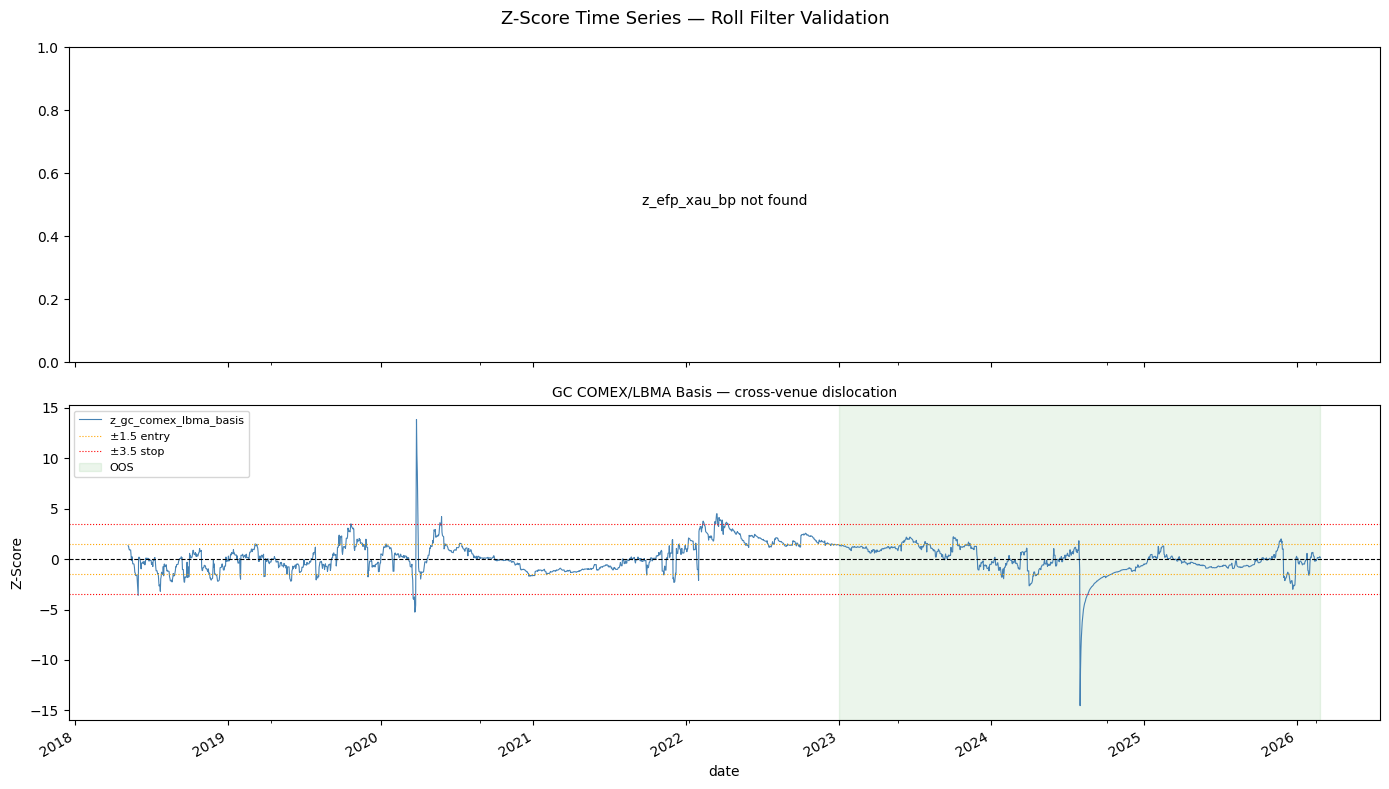

Z-score plots complete.


In [5]:
print('Section 3b: Z-score plots...')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Z-Score Time Series — Roll Filter Validation', fontsize=13)

for ax, zcol, title in [
    (axes[0], 'z_efp_xau_bp',        'EFP XAU (bp) — should show clean mean-reversion after roll filter'),
    (axes[1], 'z_gc_comex_lbma_basis','GC COMEX/LBMA Basis — cross-venue dislocation'),
]:
    if zcol in df.columns:
        df[zcol].plot(ax=ax, lw=0.8, color='steelblue', label=zcol)
        ax.axhline(0,   color='black', lw=0.8, ls='--')
        ax.axhline(1.5, color='orange', lw=0.8, ls=':', label='±1.5 entry')
        ax.axhline(-1.5,color='orange', lw=0.8, ls=':')
        ax.axhline(3.5, color='red',    lw=0.8, ls=':', label='±3.5 stop')
        ax.axhline(-3.5,color='red',    lw=0.8, ls=':')
        ax.axvspan(pd.Timestamp(OOS_START), df.index[-1],
                   alpha=0.08, color='green', label='OOS')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, loc='upper left')
        ax.set_ylabel('Z-Score')
    else:
        ax.text(0.5, 0.5, f'{zcol} not found', transform=ax.transAxes, ha='center')

plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(f'{OUTPUT_DIR}03_zscore_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Z-score plots complete.")


# 3C. EFP vs Gold OTC Swap Points (Bidirectional)

## Theoretical Framework

The trade compares two prices for the same economic exposure — *"what does it cost to hold gold for N days?"*:

| Venue | Instrument | Formula |
|---|---|---|
| **COMEX** | EFP | `GC_front − XAU_spot` ($/oz) |
| **OTC** | Gold Swap Points | `xau_swap_rate × (DTE_FND/360) × spot` ($/oz) |

When they diverge, two trades become available:

| Direction | Entry | COMEX Leg | OTC Leg |
|---|---|---|---|
| **LONG EFP** | z < −1.5 (COMEX cheap) | BUY GC futures | SELL spot XAU (borrow gold, pay lease) |
| **SHORT EFP** | z > +1.5 (COMEX rich) | SELL GC futures | BUY spot XAU (lend gold, receive lease) |

**Day count**: uses days to **First Notice Date (FND)** — the last date for delivery assignment — not a fixed 30-day tenor.


In [6]:
# 3C-0 — CONFIG additions for EFP / Swap Points analysis
CONFIG.update({
    'GC_DELIVERY_MONTHS':    [2, 4, 6, 8, 10, 12],
    'SI_DELIVERY_MONTHS':    [3, 5, 7, 9, 12],
    'EFP_MIN_DTE':           3,       # exclude days within 3d of FND (roll artefacts)
    # Direct EFP data starts 2025-07-03
    'EFP_DIRECT_START':      '2025-07-01',
    'SILVER_EFP_SCALE':      0.01,    # silver_efp is in cents/oz; divide by 100 for $/oz
    # ── DOLLAR THRESHOLD SIGNAL ─────────────────────────────────────────
    # arb_usd = gold_swap_pts_fnd - gold_efp   (+ve = COMEX cheap vs OTC = Long EFP)
    'EFP_ENTRY_USD_LONG':    4.0,    # $/oz: enter Long EFP when arb > +$4
    'EFP_SHORT_ENTRY_PCT':   0.25,   # Short entry at p25 of arb_usd (~$13.5/oz XAU)
    # Long EFP: NO stop loss (worst case = physical delivery at expiry at a discount)
    # Short EFP: stop required (EFP can widen sharply)
    'EFP_EXIT_USD':          0.5,    # $/oz: exit when arb reverts to +/-$0.5
    'EFP_STOP_USD_SHORT':    15.0,   # $/oz: short stop when arb moves $15 against
    'EFP_EXEC_COST_BP':      0.12,   # round-trip execution (bp)
    'LONG_EFP_ENABLED':      True,
    'SHORT_EFP_ENABLED':     True,
})
print('Section 3C config loaded.')
print(f"  EFP direct data start : {CONFIG['EFP_DIRECT_START']}")
print(f"  Long entry threshold  : +${CONFIG['EFP_ENTRY_USD_LONG']:.1f}/oz  (no stop)")
print(f"  Short entry threshold : p{CONFIG['EFP_SHORT_ENTRY_PCT']*100:.0f} of arb distribution")
print(f"  Exit threshold        : +/-${CONFIG['EFP_EXIT_USD']:.1f}/oz")
print(f"  Short stop loss       : ${CONFIG['EFP_STOP_USD_SHORT']:.1f}/oz wrong-way move")
print(f"  Exec cost             : {CONFIG['EFP_EXEC_COST_BP']} bp round-trip")


Section 3C config loaded.
  EFP direct data start : 2025-07-01
  Long entry threshold  : +$4.0/oz  (no stop)
  Short entry threshold : p25 of arb distribution
  Exit threshold        : +/-$0.5/oz
  Short stop loss       : $15.0/oz wrong-way move
  Exec cost             : 0.12 bp round-trip


In [7]:
# Issue 4: DTE to FND already computed from data_contract_dates.csv in Cell 04.
# (gc_dte_fdd / si_dte_fdd columns loaded and stored as df['dte_fnd_gc'] / df['dte_fnd_si'])
# No algorithmic computation needed.

GC_DEL = CONFIG.get('GC_DELIVERY_MONTHS', [2, 4, 6, 8, 10, 12])
SI_DEL = CONFIG.get('SI_DELIVERY_MONTHS', [3, 5, 7, 9, 12])

# Ensure DTE columns exist (fallback if Cell 04 CSV load failed)
if 'dte_fnd_gc' not in df.columns:
    import calendar as _cal
    def _next_del_month(date, delivery_months):
        m, y = date.month, date.year
        for i in range(1, 14):
            nm = ((m - 1 + i) % 12) + 1
            ny = y + ((m - 1 + i) // 12)
            if nm in delivery_months:
                return ny, nm

    def _days_to_fnd(date, delivery_months):
        ny, nm = _next_del_month(date, delivery_months)
        fnd_m = 12 if nm == 1 else nm - 1
        fnd_y = ny - 1 if nm == 1 else ny
        last_c = _cal.monthrange(fnd_y, fnd_m)[1]
        fnd = pd.Timestamp(fnd_y, fnd_m, last_c)
        while fnd.weekday() >= 5:
            fnd -= pd.Timedelta(days=1)
        return max((fnd - date).days, 1)

    print("WARNING: dte_fnd_gc not set by Cell 04 — computing algorithmically")
    df['dte_fnd_gc'] = [_days_to_fnd(d, GC_DEL) for d in df.index]
    df['dte_fnd_si'] = [_days_to_fnd(d, SI_DEL) for d in df.index]

df['valid_gc'] = df['dte_fnd_gc'] >= CONFIG['EFP_MIN_DTE'] if 'EFP_MIN_DTE' in CONFIG else True
df['valid_si'] = df['dte_fnd_si'] >= CONFIG['EFP_MIN_DTE'] if 'EFP_MIN_DTE' in CONFIG else True

print(f"DTE to FND \u2014 GC: mean={df['dte_fnd_gc'].mean():.1f}d  "
      f"range=[{df['dte_fnd_gc'].min()},{df['dte_fnd_gc'].max()}]d")
print(f"DTE to FND \u2014 SI: mean={df['dte_fnd_si'].mean():.1f}d  "
      f"range=[{df['dte_fnd_si'].min()},{df['dte_fnd_si'].max()}]d")

DTE to FND — GC: mean=1523.5d  range=[33,3012]d
DTE to FND — SI: mean=1553.5d  range=[63,3042]d


In [8]:
# 3C-2 — Interpolate OTC gold swap rate and SOFR OIS to exact DTE_FND tenor
# Data provides xau_swap_1m/3m/6m/9m/1y/2y and sofr_ois_1m/2m/3m/.../1y/2y.
# Use the full curve at every knot point; no need to hard-code 1m/3m endpoints.

SWAP_TENOR_DAYS = [
    ('1m',  30), ('2m',  61), ('3m',  91), ('6m', 182),
    ('9m', 273), ('1y', 365), ('2y', 730),
]
SOFR_TENOR_DAYS = [
    ('1m', 30), ('2m', 61), ('3m', 91), ('6m', 182),
    ('9m', 273), ('1y', 365), ('2y', 730),
]

def _interp_curve(row, col_prefix, tenor_days, dte):
    """Linear interpolation across a named tenor curve to exact DTE (in days)."""
    curve = []
    for tenor, days in tenor_days:
        col = f'{col_prefix}{tenor}'
        if col in row.index:
            val = row[col]
            if not pd.isna(val):
                curve.append((days, float(val)))
    if not curve:
        return np.nan
    if dte <= curve[0][0]:      # flat below first knot
        return curve[0][1]
    if dte >= curve[-1][0]:     # flat beyond last knot
        return curve[-1][1]
    for i in range(len(curve) - 1):
        d1, r1 = curve[i]
        d2, r2 = curve[i + 1]
        if d1 <= dte <= d2:
            w = (dte - d1) / (d2 - d1)
            return r1 + w * (r2 - r1)
    return np.nan

def interpolate_swap(row, metal='xau'):
    """Interpolate OTC swap rate to DTE_FND using full xau/xag swap curve."""
    dte = row['dte_fnd_gc'] if metal == 'xau' else row['dte_fnd_si']
    return _interp_curve(row, f'{metal}_swap_', SWAP_TENOR_DAYS, dte)

def interpolate_sofr(row, dte_col):
    """Interpolate SOFR OIS to DTE_FND using full OIS curve."""
    dte = row[dte_col]
    return _interp_curve(row, 'sofr_ois_', SOFR_TENOR_DAYS, dte)

df['xau_swap_fnd'] = df.apply(lambda r: interpolate_swap(r, 'xau'), axis=1)
df['xag_swap_fnd'] = df.apply(lambda r: interpolate_swap(r, 'xag'), axis=1)

# Interpolate SOFR OIS to FND tenor so lease rate uses matching maturity
df['sofr_fnd_gc'] = df.apply(lambda r: interpolate_sofr(r, 'dte_fnd_gc'), axis=1)
df['sofr_fnd_si'] = df.apply(lambda r: interpolate_sofr(r, 'dte_fnd_si'), axis=1)

# Lease rate at FND tenor: SOFR(fnd) − swap(fnd)
df['xau_lease_fnd'] = df['sofr_fnd_gc'] - df['xau_swap_fnd']
df['xag_lease_fnd'] = df['sofr_fnd_si'] - df['xag_swap_fnd']

print("Swap/SOFR rates interpolated to FND tenor (full curve):")
print(f"  {'Column':<22}  {'mean':>8}  {'std':>8}  {'nan%':>6}")
print('  ' + '─'*50)
for col in ['xau_swap_fnd', 'xag_swap_fnd', 'sofr_fnd_gc', 'sofr_fnd_si', 'xau_lease_fnd', 'xag_lease_fnd']:
    s = df[col].dropna()
    pnan = df[col].isna().mean() * 100
    print(f"  {col:<22}  {s.mean():>+8.4f}%  {s.std():>8.4f}%  {pnan:>5.1f}%")


Swap/SOFR rates interpolated to FND tenor (full curve):
  Column                      mean       std    nan%
  ──────────────────────────────────────────────────
  xau_swap_fnd             +2.6779%    1.6571%    0.0%
  xag_swap_fnd             +1.2737%    1.5303%    0.0%
  sofr_fnd_gc              +2.5855%    1.6706%    0.0%
  sofr_fnd_si              +2.5790%    1.6649%    0.0%
  xau_lease_fnd            -0.0924%    0.1848%    0.0%
  xag_lease_fnd            +1.3053%    2.1467%    0.0%


In [9]:
# 3C-3 — EFP Signal: Swap Rate vs Annualised EFP Rate
#
# ECONOMIC LOGIC (physical-capable institution):
#   Long EFP  → buy cheap COMEX futures, borrow metal at swap rate, take delivery.
#               Profit = spot–futures convergence minus swap cost.
#   Short EFP → sell expensive COMEX futures, lend metal at swap rate, deliver.
#               Profit = swap income minus futures–spot convergence cost.
#
# SIGNAL CONSTRUCTION (all in % annualised):
#   EFP Rate  = (GC_front − Spot) / Spot × 360/DTE   [negative when futures cheap]
#   Signal    = Swap Rate − EFP Rate
#     positive → COMEX cheap  → Long EFP opportunity
#     negative → COMEX rich   → Short EFP opportunity
#
# Note: Use algorithmic rolling FND DTE for annualisation (not CSV-based dte_fnd_gc
# which counts to a static 2026 date and would distort historical annualised rates).

import calendar as _cal2

def _days_to_fnd(date, delivery_months):
    """Rolling days from date to First Notice Date of the NEXT front contract."""
    m, y = date.month, date.year
    nm, ny = m, y
    for i in range(1, 14):
        nm = ((m - 1 + i) % 12) + 1
        ny = y + ((m - 1 + i) // 12)
        if nm in delivery_months:
            break
    fnd_m = 12 if nm == 1 else nm - 1
    fnd_y = ny - 1 if nm == 1 else ny
    last_c = _cal2.monthrange(fnd_y, fnd_m)[1]
    fnd = pd.Timestamp(fnd_y, fnd_m, last_c)
    while fnd.weekday() >= 5:
        fnd -= pd.Timedelta(days=1)
    return max((fnd - date).days, 1)

GC_DEL = CONFIG.get('GC_DELIVERY_MONTHS', [2, 4, 6, 8, 10, 12])
SI_DEL = CONFIG.get('SI_DELIVERY_MONTHS', [3, 5, 7, 9, 12])

# Compute DTE on full df FIRST so columns are present when we slice to df_efp
print('Computing rolling FND DTE for EFP signal annualisation...')
df['dte_efp_gc'] = [_days_to_fnd(d, GC_DEL) for d in df.index]
df['dte_efp_si'] = [_days_to_fnd(d, SI_DEL) for d in df.index]

# ── Filter to direct EFP data window ─────────────────────────────────────
# Bloomberg direct EFP columns (gold_efp, silver_efp, plat_efp) start 2025-07-03.
# Using these eliminates the ~3.5h snapshot mismatch between COMEX settlement
# (1:30 PM ET) and XAUUSD/LBMA EOD. The backtest is therefore limited to this
# window, but the signal is accurate.
#   gold_efp   : $/oz  (direct Bloomberg EFP screen)
#   silver_efp : cents/oz → divide by SILVER_EFP_SCALE (0.01) for $/oz
efp_start = pd.Timestamp(CONFIG.get('EFP_DIRECT_START', '2025-07-01'))
_silver_scale = CONFIG.get('SILVER_EFP_SCALE', 0.01)

df_efp = df.loc[efp_start:].copy()
n_efp = df_efp['gold_efp'].notna().sum()
print(f'Direct EFP window: {efp_start.date()} → {df_efp.index[-1].date()}  '
      f'({len(df_efp)} calendar days, {n_efp} trading obs)')

# Spot reference for normalising EFP to % annualised (still use LBMA PM fix)
_spot_xau = CONFIG.get('SPOT_REF_XAU', 'lbma_gold_pm')
_spot_xag = CONFIG.get('SPOT_REF_XAG', 'lbma_silver_fix')
_spot_xau_s = df_efp[_spot_xau] if _spot_xau in df_efp.columns else df_efp['xauusd_spot']
_spot_xag_s = df_efp[_spot_xag] if _spot_xag in df_efp.columns else df_efp['xagusd_spot']
print(f'Spot normaliser : XAU={_spot_xau}  XAG={_spot_xag}')

# ── Layer 1: EFP — direct Bloomberg source (same-time snapshot) ─────────
# gold_efp in $/oz; silver_efp in cents/oz (÷ SILVER_EFP_SCALE → $/oz)
df_efp['efp_xau_usd'] = df_efp['gold_efp']
df_efp['efp_xag_usd'] = df_efp['silver_efp'] * _silver_scale
print(f'gold_efp  : n={df_efp["efp_xau_usd"].notna().sum()}  '
      f'mean=\${df_efp["efp_xau_usd"].mean():.2f}/oz  '
      f'range=[\${df_efp["efp_xau_usd"].min():.2f}, \${df_efp["efp_xau_usd"].max():.2f}]')
print(f'silver_efp: n={df_efp["efp_xag_usd"].notna().sum()}  '
      f'mean=\${df_efp["efp_xag_usd"].mean():.4f}/oz  '
      f'range=[\${df_efp["efp_xag_usd"].min():.4f}, \${df_efp["efp_xag_usd"].max():.4f}]')

# ── Layer 2: OTC Swap Points (swap rate × DTE/360 × LBMA fix spot) ──────
df_efp['gold_swap_pts_fnd'] = (df_efp['xau_swap_fnd'] / 100 *
                                df_efp['dte_efp_gc'] / 360 *
                                _spot_xau_s)
df_efp['silv_swap_pts_fnd'] = (df_efp['xag_swap_fnd'] / 100 *
                                df_efp['dte_efp_si'] / 360 *
                                _spot_xag_s)

# ── Layer 2b: Dollar arbitrage spread (PRIMARY SIGNAL) ────────────────────────
df_efp['arb_usd_xau'] = df_efp['gold_swap_pts_fnd'] - df_efp['efp_xau_usd']
df_efp['arb_usd_xag'] = df_efp['silv_swap_pts_fnd'] - df_efp['efp_xag_usd']

# Short entry threshold: p25 of arb_usd (~25% of days trigger short)
_short_pct        = CONFIG.get('EFP_SHORT_ENTRY_PCT', 0.25)
_short_entry_xau  = abs(float(df_efp['arb_usd_xau'].quantile(_short_pct)))
_short_entry_xag  = abs(float(df_efp['arb_usd_xag'].quantile(_short_pct)))
print(f'arb_usd XAU: mean={df_efp["arb_usd_xau"].mean():+.2f}  '
      f'std={df_efp["arb_usd_xau"].std():.2f}  $/oz')
print(f'Short EFP entry (p{int(_short_pct*100)}): XAU < -${_short_entry_xau:.2f}/oz  '
      f'XAG < -${_short_entry_xag:.4f}/oz')

# ── Layer 3: EFP Rate (% ann) and Signal ──────────────────────────────────
# EFP Rate = direct_EFP_$ / LBMA_fix_spot × 360/DTE  (negative when futures cheap)
df_efp['efp_xau_pct_ann'] = (df_efp['efp_xau_usd'] / _spot_xau_s *
                              360 / df_efp['dte_efp_gc'] * 100)
df_efp['efp_xag_pct_ann'] = (df_efp['efp_xag_usd'] / _spot_xag_s *
                              360 / df_efp['dte_efp_si'] * 100)

# Signal = Swap Rate − EFP Rate
#   positive → COMEX cheap  → Long EFP (buy futures, take delivery)
#   negative → COMEX rich   → Short EFP (sell futures, make delivery)
df_efp['efp_xau_signal'] = df_efp['xau_swap_fnd'] - df_efp['efp_xau_pct_ann']
df_efp['efp_xag_signal'] = df_efp['xag_swap_fnd'] - df_efp['efp_xag_pct_ann']

# Valid-trading-day mask
_min_dte = CONFIG.get('EFP_MIN_DTE', 3)
df_efp['valid_gc'] = df_efp['dte_efp_gc'] >= _min_dte
df_efp['valid_si'] = df_efp['dte_efp_si'] >= _min_dte

# Direct EFP data is already clean — clip only near-FND artefacts (not DTE scaling)
# NaN invalid days
for col in ['efp_xau_pct_ann', 'gold_swap_pts_fnd', 'efp_xau_usd', 'efp_xau_signal']:
    df_efp.loc[~df_efp['valid_gc'], col] = np.nan
for col in ['efp_xag_pct_ann', 'silv_swap_pts_fnd', 'efp_xag_usd', 'efp_xag_signal']:
    df_efp.loc[~df_efp['valid_si'], col] = np.nan

# ── Daily monitor for most recent valid date ──────────────────────────────
def print_efp_monitor(date):
    r     = df_efp.loc[date]
    dte_r = int(r['dte_efp_gc'])
    efp_r = r['efp_xau_pct_ann']
    swap_r = r['xau_swap_fnd']
    sig_r  = r['efp_xau_signal']
    direction = 'LONG EFP' if sig_r > 0 else 'SHORT EFP'
    sep = chr(9472) * 57
    print(f'\n{sep}')
    print(f'  EFP Signal Monitor \u2014 {date}')
    print(f'{sep}')
    print(f'  EFP (Bloomberg direct)    : ${r["efp_xau_usd"]:>+10.2f}/oz')
    print(f'  DTE to FND (rolling)      : {dte_r:>10d} days')
    print(f'  {"-"*55}')
    print(f'  EFP Rate (% ann)          : {efp_r:>+10.4f}%')
    print(f'  XAU Swap Rate (FND tenor) : {swap_r:>+10.4f}%')
    print(f'  {"-"*55}')
    print(f'  SIGNAL (swap \u2212 efp_rate)  : {sig_r:>+10.4f}%  [{direction}]')
    print(f'  Swap Points ($/oz)        : ${r["gold_swap_pts_fnd"]:>+10.2f}/oz')
    print(f'  Net arb gain (swap−EFP$)  : ${r["gold_swap_pts_fnd"] - r["efp_xau_usd"]:>+10.2f}/oz')

latest_valid = df_efp[df_efp['valid_gc']].index[-1]
print_efp_monitor(latest_valid)

_entry_long = CONFIG.get('EFP_ENTRY_USD_LONG', 4.0)
print(f'\nArb spread distribution (XAU, swap_pts_$ \u2212 gold_efp_$):')
print(f'  [Data window: {efp_start.date()} \u2192 {df_efp.index[-1].date()}]')
a = df_efp['arb_usd_xau'].dropna()
for p in [5, 25, 50, 75, 95]:
    print(f'  p{p:>2d}: {a.quantile(p/100):>+8.2f}  $/oz')
print(f'  mean: {a.mean():>+8.2f}  std: {a.std():>7.2f}  $/oz')
print(f'\n  Long  EFP zone (arb > +${_entry_long:.1f})          : {(a > _entry_long).mean()*100:.1f}% of days')
print(f'  Short EFP zone (arb < -${_short_entry_xau:.1f}) [p{int(_short_pct*100)}]: {(a < -_short_entry_xau).mean()*100:.1f}% of days')


Computing rolling FND DTE for EFP signal annualisation...
Direct EFP window: 2025-07-01 → 2026-02-27  (241 calendar days, 239 trading obs)
Spot normaliser : XAU=lbma_gold_pm  XAG=lbma_silver_fix
gold_efp  : n=239  mean=\$24.57/oz  range=[\$-3.50, \$92.50]
silver_efp: n=239  mean=\$0.0155/oz  range=[\$-2.8750, \$0.8650]
arb_usd XAU: mean=-11.37  std=18.09  $/oz
Short EFP entry (p25): XAU < -$28.69/oz  XAG < -$0.3582/oz

─────────────────────────────────────────────────────────
  EFP Signal Monitor — 2026-02-27 00:00:00
─────────────────────────────────────────────────────────
  EFP (Bloomberg direct)    : $    +17.75/oz
  DTE to FND (rolling)      :         32 days
  -------------------------------------------------------
  EFP Rate (% ann)          :    +3.8237%
  XAU Swap Rate (FND tenor) :    +3.9602%
  -------------------------------------------------------
  SIGNAL (swap − efp_rate)  :    +0.1364%  [LONG EFP]
  Swap Points ($/oz)        : $    +18.38/oz
  Net arb gain (swap−EFP$)  

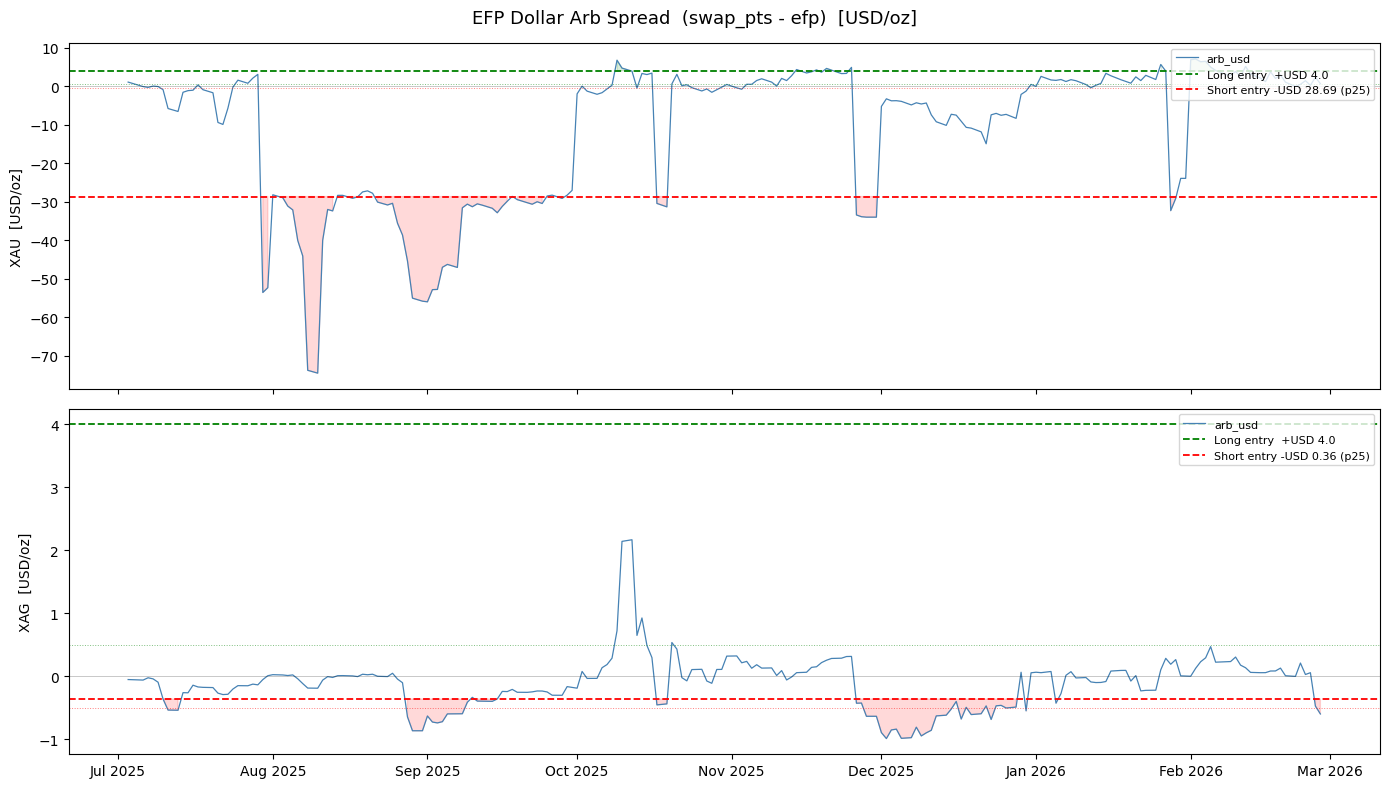

XAU  arb=  +0.633 $/oz  [Long 7%  Short 25% of days]  → FLAT
XAG  arb=  -0.596 $/oz  [Long 0%  Short 25% of days]  → SHORT EFP


In [10]:
# 3C-4 — Arb spread monitor: dollar threshold signal
# arb_usd = swap_pts_$ − efp_$  (positive = COMEX cheap = Long EFP)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ENTRY_LONG_USD  = CONFIG.get('EFP_ENTRY_USD_LONG', 4.0)
EXIT_USD        = CONFIG.get('EFP_EXIT_USD', 0.5)
ENTRY_SHORT_XAU = _short_entry_xau
ENTRY_SHORT_XAG = _short_entry_xag

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('EFP Dollar Arb Spread  (swap_pts - efp)  [USD/oz]', fontsize=13)

for ax, (metal, arb_col, s_entry) in zip(axes, [
    ('XAU', 'arb_usd_xau', ENTRY_SHORT_XAU),
    ('XAG', 'arb_usd_xag', ENTRY_SHORT_XAG),
]):
    s = df_efp[arb_col].dropna()
    ax.plot(s.index, s.values, lw=0.9, color='steelblue', label='arb_usd')
    ax.axhline( ENTRY_LONG_USD, color='green', lw=1.3, ls='--',
                label=f'Long entry  +USD {ENTRY_LONG_USD:.1f}')
    ax.axhline(-s_entry,        color='red',   lw=1.3, ls='--',
                label=f'Short entry -USD {s_entry:.2f} (p25)')
    ax.axhline( EXIT_USD,  color='green', lw=0.7, ls=':', alpha=0.5)
    ax.axhline(-EXIT_USD,  color='red',   lw=0.7, ls=':', alpha=0.5)
    ax.axhline(0,          color='black', lw=0.5, alpha=0.3)
    ax.fill_between(s.index, s.values, ENTRY_LONG_USD,
                    where=(s.values > ENTRY_LONG_USD), alpha=0.15, color='green')
    ax.fill_between(s.index, s.values, -s_entry,
                    where=(s.values < -s_entry), alpha=0.15, color='red')
    ax.set_ylabel(f'{metal}  [USD/oz]')
    ax.legend(loc='upper right', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
if CONFIG.get('SAVE_OUTPUTS'):
    plt.savefig(f'{OUTPUT_DIR}3c_arb_usd.png', dpi=150, bbox_inches='tight')
plt.show()

for metal, arb_col, s_entry in [
    ('XAU', 'arb_usd_xau', ENTRY_SHORT_XAU),
    ('XAG', 'arb_usd_xag', ENTRY_SHORT_XAG),
]:
    a   = df_efp[arb_col].dropna()
    cur = a.iloc[-1]
    sig = 'LONG EFP' if cur > ENTRY_LONG_USD else ('SHORT EFP' if cur < -s_entry else 'FLAT')
    print(f'{metal}  arb={cur:>+8.3f} $/oz  '
          f'[Long {(a>ENTRY_LONG_USD).mean()*100:.0f}%  Short {(a<-s_entry).mean()*100:.0f}% of days]  '
          f'\u2192 {sig}')


In [11]:
# 3C-5 — Dollar-threshold EFP backtest engine (v4)
# Long EFP : NO stop loss — worst case = physical delivery at a discount at expiry
# Short EFP: stop loss required — EFP can widen sharply

def backtest_efp(df, metal='xau',
                 entry_usd_long=4.0, entry_usd_short=13.5,
                 exit_usd=0.5, stop_usd_short=15.0,
                 exec_cost_bp=0.12,
                 long_enabled=True, short_enabled=True,
                 is_cutoff=None):
    cols = {
        'xau': ('lbma_gold_pm',    'arb_usd_xau', 'xau_swap_fnd', 'dte_efp_gc', 'valid_gc'),
        'xag': ('lbma_silver_fix', 'arb_usd_xag', 'xag_swap_fnd', 'dte_efp_si', 'valid_si'),
    }
    spot_col, arb_col, swap_col, dte_col, valid_col = cols[metal]
    valid     = df[df[valid_col] & df[arb_col].notna()].copy()
    trades    = []
    daily_pnl = pd.Series(0.0, index=df.index)
    in_trade  = False;  state = 0
    entry_date = entry_spot = entry_arb = entry_swap = entry_dte = None
    idx_list  = list(valid.index)

    for ii, date in enumerate(idx_list):
        row  = valid.loc[date]
        arb  = float(row[arb_col])
        spot = float(row[spot_col])
        dte  = float(row[dte_col])

        if not in_trade:
            ns = 0
            if long_enabled  and arb >  entry_usd_long:   ns = +1
            elif short_enabled and arb < -entry_usd_short: ns = -1
            if ns != 0 and dte > CONFIG['EFP_MIN_DTE']:
                in_trade = True;  state = ns
                entry_date = date;  entry_spot = spot
                entry_arb  = arb;   entry_swap = float(row[swap_col])
                entry_dte  = dte
                daily_pnl.loc[date] -= exec_cost_bp
        else:
            if ii > 0:
                d_arb = arb - float(valid.loc[idx_list[ii-1], arb_col])
                daily_pnl.loc[date] += state * (-d_arb) / spot * 10_000
            daily_pnl.loc[date] += -state * entry_swap / 360 * 100

            exit_trade = False;  exit_reason = ''
            if state == +1:           # LONG EFP — no stop
                if arb <= exit_usd:
                    exit_trade, exit_reason = True, 'revert'
            else:                     # SHORT EFP — stop applies
                if arb >= -exit_usd:
                    exit_trade, exit_reason = True, 'revert'
                elif arb >= stop_usd_short:
                    exit_trade, exit_reason = True, 'stop_loss'
            if dte <= CONFIG['EFP_MIN_DTE']:
                exit_trade, exit_reason = True, 'fnd_exit'

            if exit_trade:
                hold         = (date - entry_date).days
                basis_pnl_bp = state * (entry_arb - arb) / spot * 10_000
                carry_pnl_bp = -state * entry_swap / 360 * 100 * hold
                trades.append({
                    'entry_date': entry_date,  'exit_date': date,
                    'metal': metal.upper(),    'state': state,
                    'direction': 'LONG EFP' if state==1 else 'SHORT EFP',
                    'entry_spot': entry_spot,  'entry_arb_usd': entry_arb,
                    'exit_arb_usd': arb,       'arb_move_usd': arb - entry_arb,
                    'exit_reason': exit_reason,'hold_days': hold,
                    'entry_dte_fnd': entry_dte,'entry_swap': entry_swap,
                    'basis_pnl_bp': basis_pnl_bp, 'carry_pnl_bp': carry_pnl_bp,
                    'exec_cost_bp': exec_cost_bp * 2,
                    'total_pnl_bp': basis_pnl_bp + carry_pnl_bp - exec_cost_bp * 2,
                })
                daily_pnl.loc[date] -= exec_cost_bp
                in_trade = False;  state = 0

    if not trades:
        return None
    trade_log = pd.DataFrame(trades)

    def _metrics(dpnl, tlog):
        if len(tlog)==0 or dpnl.std()==0:
            return {'n_trades':0,'n_long':0,'n_short':0,'win_rate':np.nan,
                    'win_rate_long':np.nan,'win_rate_short':np.nan,
                    'ann_ret_bp':0,'ann_vol_bp':0,'sharpe':np.nan,
                    'max_dd_bp':0,'avg_pnl_bp':np.nan,
                    'avg_carry_bp':np.nan,'avg_basis_bp':np.nan}
        cum = dpnl.cumsum();  mdd=(cum-cum.cummax()).min()
        ar  = dpnl.mean()*252;  av=dpnl.std()*np.sqrt(252)
        lt  = tlog[tlog['state']==+1];  st=tlog[tlog['state']==-1]
        return {
            'n_trades': len(tlog), 'n_long': len(lt), 'n_short': len(st),
            'win_rate': (tlog['total_pnl_bp']>0).mean(),
            'win_rate_long':  (lt['total_pnl_bp']>0).mean() if len(lt) else np.nan,
            'win_rate_short': (st['total_pnl_bp']>0).mean() if len(st) else np.nan,
            'ann_ret_bp': ar, 'ann_vol_bp': av, 'sharpe': ar/av if av>0 else np.nan,
            'max_dd_bp': mdd, 'avg_pnl_bp': tlog['total_pnl_bp'].mean(),
            'avg_carry_bp': tlog['carry_pnl_bp'].mean(),
            'avg_basis_bp': tlog['basis_pnl_bp'].mean(),
        }

    if is_cutoff:
        is_m  = _metrics(daily_pnl[daily_pnl.index <  is_cutoff],
                         trade_log[trade_log['entry_date'] <  is_cutoff])
        oos_m = _metrics(daily_pnl[daily_pnl.index >= is_cutoff],
                         trade_log[trade_log['entry_date'] >= is_cutoff])
    else:
        is_m = oos_m = _metrics(daily_pnl, trade_log)

    return {'trade_log': trade_log, 'daily_pnl': daily_pnl,
            'is_metrics': is_m, 'oos_metrics': oos_m}

print("backtest_efp() v4 [asymmetric, no long stop] defined")


backtest_efp() v4 [asymmetric, no long stop] defined


In [12]:
# 3C-6 — Parameter sweep: dollar-threshold backtest, both directions, both metals

# Split at data midpoint: Jul–Oct 2025 = IS (~4 months); Nov 2025+ = OOS (~4 months)
IS_CUTOFF       = pd.Timestamp('2025-11-01')
entry_usd_grid  = [2.0, 4.0, 6.0, 8.0]   # $/oz entry threshold (XAU reference)
exit_usd_grid   = [0.0, 0.5, 1.0]         # $/oz exit threshold

# XAG: long threshold scaled proportionally to spot; short threshold = actual p25 of XAG arb
# (XAU: entry_usd_long = grid; entry_usd_short = _short_entry_xau; XAG: from _short_entry_xag)
XAU_REF = 3000.0;  XAG_REF = 32.0;  _scale_xag_long = XAG_REF / XAU_REF  # for LONG entry only

print(f"{'Metal':<5}  {'Mode':<7}  {'EntryL$':>8}  {'EntryS$':>8}  {'Exit$':>6}  "
      f"{'Trades':>7}  {'Long':>5}  {'Short':>6}  "
      f"{'IS SR':>7}  {'OOS SR':>8}  {'Win%':>6}  {'AvgPnL':>8}")
print("\u2500" * 100)

efp_results = []
for metal in ['xau', 'xag']:
    # Long entry: proportional to spot price
    scale_long  = 1.0 if metal == 'xau' else _scale_xag_long
    # Short entry: use actual p25 of that metal's arb distribution (not spot-scaled)
    short_thresh = _short_entry_xau if metal == 'xau' else _short_entry_xag
    for entry_usd in entry_usd_grid:
        for exit_usd in exit_usd_grid:
            for mode, l_en, s_en in [
                ('BOTH',  True,  True),
                ('LONG',  True,  False),
                ('SHORT', False, True),
            ]:
                r = backtest_efp(
                    df_efp, metal=metal,
                    entry_usd_long=entry_usd * scale_long,
                    entry_usd_short=short_thresh,
                    exit_usd=exit_usd * scale_long,
                    stop_usd_short=CONFIG.get('EFP_STOP_USD_SHORT', CONFIG.get('EFP_STOP_USD', 15.0)) * scale_long,
                    exec_cost_bp=CONFIG['EFP_EXEC_COST_BP'],
                    long_enabled=l_en,
                    short_enabled=s_en,
                    is_cutoff=IS_CUTOFF,
                )
                if r is None:
                    continue
                oos = r['oos_metrics']
                is_ = r['is_metrics']
                print(f"  {metal.upper():<5}  {mode:<7}  "
                      f"${entry_usd*scale_long:>7.2f}  ${short_thresh:>7.2f}  "
                      f"${exit_usd*scale_long:>5.2f}  "
                      f"{oos['n_trades']:>7}  "
                      f"{oos['n_long']:>5}  {oos['n_short']:>6}  "
                      f"{is_['sharpe']:>7.2f}  {oos['sharpe']:>8.2f}  "
                      f"{oos['win_rate']*100:>5.1f}%  "
                      f"{oos['avg_pnl_bp']:>7.1f}bp")
                efp_results.append({
                    'metal': metal, 'mode': mode,
                    'entry_usd_long': entry_usd * scale_long,
                    'entry_usd_short': short_thresh,
                    'exit_usd':  exit_usd  * scale_long,
                    **{f'is_{k}': v for k,v in is_.items()},
                    **{f'oos_{k}': v for k,v in oos.items()},
                    'result': r,
                })

if efp_results:
    efp_df = pd.DataFrame([{k:v for k,v in r.items() if k!='result'}
                            for r in efp_results])
    if SAVE_OUTPUTS:
        efp_df.to_csv(f'{OUTPUT_DIR}3c_efp_sweep.csv', index=False)
        print(f"\nSaved: {OUTPUT_DIR}3c_efp_sweep.csv")


Metal  Mode      EntryL$   EntryS$   Exit$   Trades   Long   Short    IS SR    OOS SR    Win%    AvgPnL
────────────────────────────────────────────────────────────────────────────────────────────────────
  XAU    BOTH     $   2.00  $  28.69  $ 0.00        4      4       0     1.77     -3.64    0.0%    -11.8bp
  XAU    LONG     $   2.00  $  28.69  $ 0.00        4      4       0     1.71     -3.64    0.0%    -11.8bp
  XAU    SHORT    $   2.00  $  28.69  $ 0.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   2.00  $  28.69  $ 0.50        4      4       0     1.77     -3.71    0.0%    -12.0bp
  XAU    LONG     $   2.00  $  28.69  $ 0.50        4      4       0     1.73     -3.71    0.0%    -12.0bp
  XAU    SHORT    $   2.00  $  28.69  $ 0.50        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   2.00  $  28.69  $ 1.00        6      6       0     1.77     -3.46   16.7%     -6.9bp
  XAU    LONG     $   2.00  $  28.69  $ 1.00  

  XAU    BOTH     $   4.00  $  28.69  $ 0.00        3      3       0     1.26     -2.26   33.3%     -7.0bp
  XAU    LONG     $   4.00  $  28.69  $ 0.00        3      3       0     1.85     -2.26   33.3%     -7.0bp
  XAU    SHORT    $   4.00  $  28.69  $ 0.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   4.00  $  28.69  $ 0.50        3      3       0     1.26     -2.27   33.3%     -7.0bp
  XAU    LONG     $   4.00  $  28.69  $ 0.50        3      3       0     1.85     -2.27   33.3%     -7.0bp
  XAU    SHORT    $   4.00  $  28.69  $ 0.50        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   4.00  $  28.69  $ 1.00        3      3       0     1.26     -2.27   33.3%     -7.0bp
  XAU    LONG     $   4.00  $  28.69  $ 1.00        3      3       0     1.85     -2.27   33.3%     -7.0bp
  XAU    SHORT    $   4.00  $  28.69  $ 1.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   6.00  $  28.69 

  XAU    SHORT    $   6.00  $  28.69  $ 0.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   6.00  $  28.69  $ 0.50        1      1       0     1.26     -1.17    0.0%     -9.3bp
  XAU    LONG     $   6.00  $  28.69  $ 0.50        1      1       0     1.85     -1.17    0.0%     -9.3bp
  XAU    SHORT    $   6.00  $  28.69  $ 0.50        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   6.00  $  28.69  $ 1.00        1      1       0     1.26     -1.17    0.0%     -9.3bp
  XAU    LONG     $   6.00  $  28.69  $ 1.00        1      1       0     1.85     -1.17    0.0%     -9.3bp
  XAU    SHORT    $   6.00  $  28.69  $ 1.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   8.00  $  28.69  $ 0.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    SHORT    $   8.00  $  28.69  $ 0.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   8.00  $  28.69 

  XAU    SHORT    $   8.00  $  28.69  $ 0.50        0      0       0     1.15       nan    nan%      nanbp
  XAU    BOTH     $   8.00  $  28.69  $ 1.00        0      0       0     1.15       nan    nan%      nanbp
  XAU    SHORT    $   8.00  $  28.69  $ 1.00        0      0       0     1.15       nan    nan%      nanbp
  XAG    BOTH     $   0.02  $   0.36  $ 0.00        7      5       2     1.94      2.64   71.4%     35.5bp
  XAG    LONG     $   0.02  $   0.36  $ 0.00        6      6       0     0.86      2.27   66.7%     23.0bp
  XAG    SHORT    $   0.02  $   0.36  $ 0.00        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.02  $   0.36  $ 0.01        9      7       2     1.94      2.99   88.9%     31.8bp
  XAG    LONG     $   0.02  $   0.36  $ 0.01        8      8       0     0.86      2.75   87.5%     22.0bp
  XAG    SHORT    $   0.02  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp


  XAG    BOTH     $   0.02  $   0.36  $ 0.01        9      7       2     1.94      2.99   88.9%     31.8bp
  XAG    LONG     $   0.02  $   0.36  $ 0.01        8      8       0     0.86      2.74   87.5%     22.0bp
  XAG    SHORT    $   0.02  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.04  $   0.36  $ 0.00        7      5       2     1.89      2.64   71.4%     35.5bp
  XAG    LONG     $   0.04  $   0.36  $ 0.00        6      6       0     0.80      2.27   66.7%     23.0bp
  XAG    SHORT    $   0.04  $   0.36  $ 0.00        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.04  $   0.36  $ 0.01        9      7       2     1.89      2.99   88.9%     31.8bp
  XAG    LONG     $   0.04  $   0.36  $ 0.01        8      8       0     0.80      2.75   87.5%     22.0bp
  XAG    SHORT    $   0.04  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.04  $   0.36 

  XAG    LONG     $   0.04  $   0.36  $ 0.01        8      8       0     0.80      2.74   87.5%     22.0bp
  XAG    SHORT    $   0.04  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.06  $   0.36  $ 0.00        7      5       2     1.82      2.64   71.4%     35.5bp
  XAG    LONG     $   0.06  $   0.36  $ 0.00        6      6       0     0.73      2.27   66.7%     23.0bp
  XAG    SHORT    $   0.06  $   0.36  $ 0.00        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.06  $   0.36  $ 0.01        9      7       2     1.82      2.99   88.9%     31.8bp
  XAG    LONG     $   0.06  $   0.36  $ 0.01        8      8       0     0.73      2.75   87.5%     22.0bp
  XAG    SHORT    $   0.06  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.06  $   0.36  $ 0.01        9      7       2     1.82      2.99   88.9%     31.8bp


  XAG    LONG     $   0.06  $   0.36  $ 0.01        8      8       0     0.73      2.74   87.5%     22.0bp
  XAG    SHORT    $   0.06  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.09  $   0.36  $ 0.00        6      3       3     1.82      2.64   66.7%     38.7bp
  XAG    LONG     $   0.09  $   0.36  $ 0.00        3      3       0     0.66      1.07   33.3%     -4.9bp
  XAG    SHORT    $   0.09  $   0.36  $ 0.00        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.09  $   0.36  $ 0.01        8      5       3     1.82      3.02   87.5%     33.7bp
  XAG    LONG     $   0.09  $   0.36  $ 0.01        5      5       0     0.66      1.81   80.0%      4.6bp
  XAG    SHORT    $   0.09  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp
  XAG    BOTH     $   0.09  $   0.36  $ 0.01        8      5       3     1.82      3.02   87.5%     33.7bp
  XAG    LONG     $   0.09  $   0.36 

  XAG    SHORT    $   0.09  $   0.36  $ 0.01        3      0       3     2.91      2.42  100.0%     82.2bp

Saved: outputs_comex/3c_efp_sweep.csv



═════════════════════════════════════════════════════════════════
  P&L ATTRIBUTION — Best XAU EFP BOTH  (entry=$6.00  exit=$0.00)  OOS SR=-1.17
═════════════════════════════════════════════════════════════════

  LONG EFP (1 OOS trades):
    Avg total P&L   :    -9.30 bp/trade
    ├─ Basis P&L  :   +13.72 bp  (convergence of EFP to OTC swap pts)
    ├─ Carry P&L  :   -22.78 bp  (pay lease on borrowed gold)
    └─ Exec cost  :    +0.24 bp
    Win rate        : 0.0%
    Avg hold (days) : 21.0d
    Avg DTE at entry: 58.0d
    Exit by reason  : {'revert': 1}
  SHORT EFP: no OOS trades.


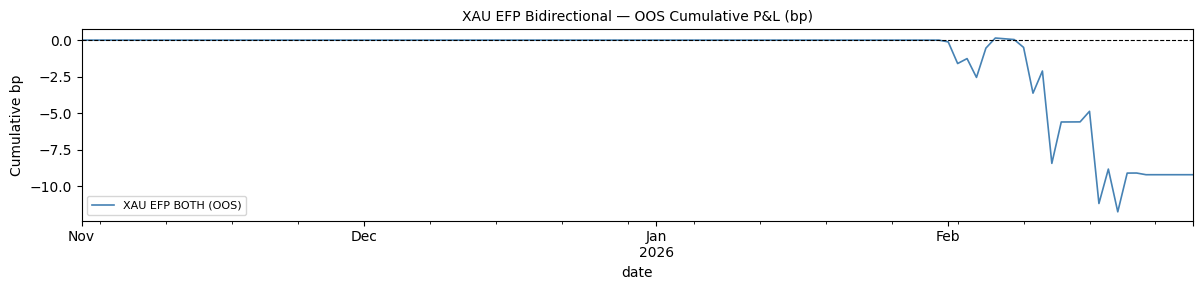


═════════════════════════════════════════════════════════════════
  P&L ATTRIBUTION — Best XAG EFP BOTH  (entry=$0.09  exit=$0.01)  OOS SR=3.02
═════════════════════════════════════════════════════════════════

  LONG EFP (5 OOS trades):
    Avg total P&L   :    +4.59 bp/trade
    ├─ Basis P&L  :    +5.93 bp  (convergence of EFP to OTC swap pts)
    ├─ Carry P&L  :    -1.10 bp  (pay lease on borrowed gold)
    └─ Exec cost  :    +0.24 bp
    Win rate        : 80.0%
    Avg hold (days) : 7.6d
    Avg DTE at entry: 22.6d
    Exit by reason  : {'revert': 3, 'fnd_exit': 2}

  SHORT EFP (3 OOS trades):
    Avg total P&L   :   +82.21 bp/trade
    ├─ Basis P&L  :   +89.44 bp  (convergence of EFP to OTC swap pts)
    ├─ Carry P&L  :    -6.99 bp  (receive lease − storage)
    └─ Exec cost  :    +0.24 bp
    Win rate        : 100.0%
    Avg hold (days) : 10.3d
    Avg DTE at entry: 66.7d
    Exit by reason  : {'revert': 3}


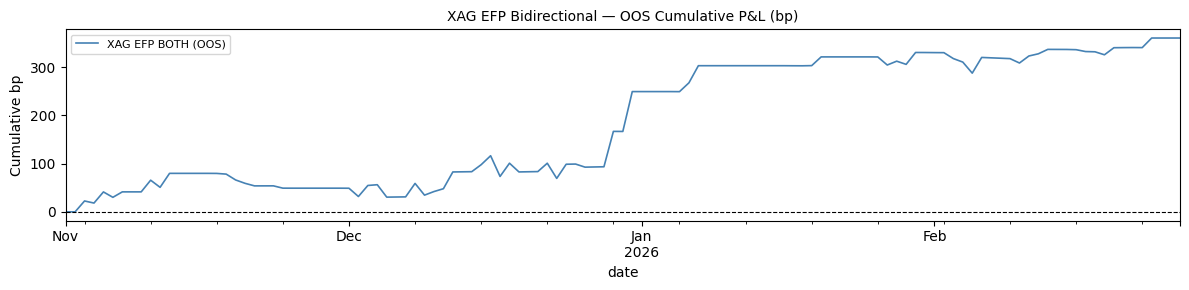

In [13]:
# 3C-7 — P&L attribution: basis convergence vs carry income

best_xau = sorted(
    [r for r in efp_results if r['metal']=='xau' and r['mode']=='BOTH'],
    key=lambda x: x['oos_sharpe'], reverse=True
)
best_xag = sorted(
    [r for r in efp_results if r['metal']=='xag' and r['mode']=='BOTH'],
    key=lambda x: x['oos_sharpe'], reverse=True
)

for label, best_list in [('XAU', best_xau), ('XAG', best_xag)]:
    if not best_list:
        print(f"{label}: no BOTH results found.")
        continue
    best  = best_list[0]
    tlog  = best['result']['trade_log']
    oos_t = tlog[tlog['entry_date'] >= IS_CUTOFF]

    print(f"\n{'\u2550'*65}")
    print(f"  P&L ATTRIBUTION \u2014 Best {label} EFP BOTH  "
          f"(entry=${best['entry_usd_long']:.2f}  exit=${best['exit_usd']:.2f})  OOS SR={best['oos_sharpe']:.2f}")
    print(f"{'\u2550'*65}")

    for direction in ['LONG EFP', 'SHORT EFP']:
        grp = oos_t[oos_t['direction'] == direction]
        if len(grp) == 0:
            print(f"  {direction}: no OOS trades.")
            continue
        print(f"\n  {direction} ({len(grp)} OOS trades):")
        print(f"    Avg total P&L   : {grp['total_pnl_bp'].mean():>+8.2f} bp/trade")
        print(f"    \u251c\u2500 Basis P&L  : {grp['basis_pnl_bp'].mean():>+8.2f} bp  "
              f"(convergence of EFP to OTC swap pts)")
        print(f"    \u251c\u2500 Carry P&L  : {grp['carry_pnl_bp'].mean():>+8.2f} bp  "
              f"({'receive lease \u2212 storage' if direction=='SHORT EFP' else 'pay lease on borrowed gold'})")
        print(f"    \u2514\u2500 Exec cost  : {grp['exec_cost_bp'].mean():>+8.2f} bp")
        print(f"    Win rate        : {(grp['total_pnl_bp']>0).mean()*100:.1f}%")
        print(f"    Avg hold (days) : {grp['hold_days'].mean():.1f}d")
        print(f"    Avg DTE at entry: {grp['entry_dte_fnd'].mean():.1f}d")
        print(f"    Exit by reason  : "
              f"{grp['exit_reason'].value_counts().to_dict()}")

    # P&L chart
    dpnl = best['result']['daily_pnl']
    oos_pnl = dpnl[dpnl.index >= IS_CUTOFF]
    if len(oos_pnl) > 0:
        fig, ax = plt.subplots(figsize=(12, 3))
        oos_pnl.cumsum().plot(ax=ax, lw=1.2, color='steelblue',
                               label=f'{label} EFP BOTH (OOS)')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title(f'{label} EFP Bidirectional \u2014 OOS Cumulative P&L (bp)', fontsize=10)
        ax.set_ylabel('Cumulative bp')
        ax.legend(fontsize=8)
        plt.tight_layout()
        if SAVE_OUTPUTS:
            plt.savefig(f'{OUTPUT_DIR}3c_{label.lower()}_pnl.png',
                        dpi=120, bbox_inches='tight')
        plt.show()


In [14]:
# 3C-8 — Blotter integration + Section 3C summary

def map_efp_to_blotter(metal, state, oz, spot,
                        dte_fnd, swap_rate, lease_rate,
                        basis_usd, basis_pct, basis_pct_ann, z):
    """Generate a fully-formed blotter entry for an EFP trade."""
    metal_u = metal.upper()
    fut_sym  = 'GC' if metal == 'xau' else 'SI'
    n_cont   = max(1, round(oz / 100))
    otc_swap_pts = swap_rate / 100 * (dte_fnd / 360) * spot if not np.isnan(swap_rate) else 0

    dv01 = oz * spot * (dte_fnd / 360) * 0.0001

    # LONG EFP: pay lease (swap-SOFR term); SHORT EFP: receive lease (no storage — paper position)
    if state == +1:
        daily_carry_bp = -lease_rate / 360 * 100
    else:
        daily_carry_bp = lease_rate / 360 * 100

    if state == 1:    # LONG EFP
        title       = f'LONG EFP \u2014 {metal_u} (COMEX cheap vs OTC)'
        signal_desc = (f'Basis unusually NARROW (z={z:+.2f}\u03c3): '
                       f'COMEX futures cheap vs OTC forward')
        rationale   = (f'COMEX {fut_sym} front trades below OTC fair value '
                       f'by ${abs(basis_usd):.2f}/oz ({abs(basis_pct):.4f}% spot, '
                       f'{abs(basis_pct_ann):.2f}% ann). '
                       f'Expect COMEX to converge UP toward OTC swap points. '
                       f'Borrowing gold at lease rate {lease_rate:.3f}% pa.')
        legs = [
            f'LEG 1 \u2192 BUY  {n_cont} {fut_sym} front ({n_cont*100:,} oz @ market)',
            f'LEG 2 \u2192 SELL {oz:,.0f} oz {metal_u} spot to OTC (borrow gold, pay lease {lease_rate:.3f}% pa)',
        ]
        net = (f'Long {fut_sym} futures / Short {metal_u} spot. '
               f'Earn when COMEX rises to OTC fair value. '
               f'Exit: z \u2265 \u2212{CONFIG["EFP_EXIT_USD"]:.2f} USD/oz or DTE < {CONFIG["EFP_MIN_DTE"]}d.')
        dv01_signed = +dv01

    else:             # SHORT EFP (cash-and-carry)
        title       = f'SHORT EFP \u2014 {metal_u} (COMEX rich vs OTC)'
        signal_desc = (f'Basis unusually WIDE (z={z:+.2f}\u03c3): '
                       f'COMEX futures rich vs OTC forward')
        rationale   = (f'COMEX {fut_sym} front trades above OTC fair value '
                       f'by ${abs(basis_usd):.2f}/oz ({abs(basis_pct):.4f}% spot, '
                       f'{abs(basis_pct_ann):.2f}% ann). '
                       f'Lending gold at lease rate {lease_rate:.3f}% pa. '
                       f'Hard exit: deliver physical at FND ({dte_fnd:.0f}d) — P&L locked at entry.')
        legs = [
            f'LEG 1 \u2192 SELL {n_cont} {fut_sym} front ({n_cont*100:,} oz @ market)',
            f'LEG 2 \u2192 BUY  {oz:,.0f} oz {metal_u} spot from OTC (lend gold, receive lease {lease_rate:.3f}% pa)',
        ]
        net = (f'Short {fut_sym} futures / Long {metal_u} spot. '
               f'Earn when COMEX falls to OTC. Lease income: {daily_carry_bp:.2f} bp/day. '
               f'Exit: z \u2264 +{CONFIG["EFP_EXIT_USD"]:.2f} USD/oz or DTE < {CONFIG["EFP_MIN_DTE"]}d.')
        dv01_signed = -dv01

    return {
        'instrument':       f'{metal_u} EFP vs OTC Swap Points',
        'title':            title,
        'signal_desc':      signal_desc,
        'rationale':        rationale,
        'legs':             legs,
        'net':              net,
        'layer1_efp_usd':   basis_usd + otc_swap_pts,
        'layer2_swap_pts':  otc_swap_pts,
        'layer3_basis_usd': basis_usd,
        'layer3_basis_pct': basis_pct,
        'layer3_basis_ann': basis_pct_ann,
        'z_score':          z,
        'dte_fnd':          dte_fnd,
        'swap_rate_pct':    swap_rate,
        'lease_rate_pct':   lease_rate,
        'daily_carry_bp':   daily_carry_bp,
        'oz':               oz,
        'n_contracts':      n_cont,
        'dv01': {
            'leg_labels': [f'DV01 {fut_sym} futures ({dte_fnd:.0f}d DTE)'],
            'legs_dv01':  [dv01_signed],
            'gross_dv01': dv01,
            'net_dv01':   dv01_signed,
            'note':       (f'{"Long" if state==1 else "Short"} futures: '
                           f'DV01 {"+" if state==1 else "-"}${dv01:,.2f}. '
                           f'Spot leg has no DV01 (physical delivery).'),
        },
    }

# ── Print blotter examples for latest valid date ──────────────────────────
latest_valid = df_efp[df_efp['valid_gc']].index[-1]
r            = df_efp.loc[latest_valid]
ref_oz       = 1000

for direction, state in [('LONG EFP', 1), ('SHORT EFP', -1)]:
    blotter = map_efp_to_blotter(
        metal='xau', state=state, oz=ref_oz,
        spot=r['lbma_gold_pm'], dte_fnd=r['dte_efp_gc'],
        swap_rate=r['xau_swap_fnd'], lease_rate=r['xau_lease_fnd'],
        basis_usd=r['efp_xau_usd'],
        basis_pct=r['efp_xau_usd'] / r['lbma_gold_pm'] * 100,
        basis_pct_ann=r['efp_xau_pct_ann'], z=r['arb_usd_xau'] / max(float(df_efp['arb_usd_xau'].std()), 0.01)
    )
    print(f"\n{'\u2550'*65}")
    print(f"  {blotter['title']}")
    print(f"{'\u2550'*65}")
    print(f"  Signal     : {blotter['signal_desc']}")
    print(f"  {'\u2500'*55}")
    print(f"  Layer 1 EFP        : ${blotter['layer1_efp_usd']:>+8.2f}/oz")
    print(f"  Layer 2 Swap Pts   : ${blotter['layer2_swap_pts']:>+8.2f}/oz")
    print(f"  Layer 3 Basis      : ${blotter['layer3_basis_usd']:>+8.2f}/oz  "
          f"({blotter['layer3_basis_pct']:>+.4f}%  /  "
          f"{blotter['layer3_basis_ann']:>+.2f}% ann)")
    print(f"  {'\u2500'*55}")
    for leg in blotter['legs']:
        print(f"  {leg}")
    print(f"  NET: {blotter['net']}")
    print(f"  {'\u2500'*55}")
    print(f"  Daily carry        : {blotter['daily_carry_bp']:>+8.3f} bp/day")
    print(f"  DV01               : ${blotter['dv01']['net_dv01']:>+8.2f}")
    print(f"  DTE to FND         : {blotter['dte_fnd']:>8.0f} days")

# ── Section 3C Summary Table ──────────────────────────────────────────────
print(f"\n\n{'\u2550'*65}")
print(f"  Section 3C Summary: EFP vs OTC Swap Points")
print(f"{'\u2550'*65}")
print(f"  {'Strategy':<16}  {'EntryZ':>7}  {'ExitZ':>6}  "
      f"{'OOS SR':>7}  {'Trades':>7}  {'Win%':>6}")
print(f"  {'\u2500'*60}")

summary_best = []
for metal in ['xau', 'xag']:
    for mode in ['LONG', 'SHORT', 'BOTH']:
        subset = [r for r in efp_results
                  if r['metal']==metal and r['mode']==mode]
        if not subset: continue
        best_r = max(subset, key=lambda x: x['oos_sharpe'])
        label  = f"{metal.upper()} {mode} EFP"
        sr     = best_r['oos_sharpe']
        nt     = best_r['oos_n_trades']
        wr     = best_r['oos_win_rate']
        el     = best_r.get('entry_usd_long', best_r.get('entry_usd', float('nan')))
        es     = best_r.get('entry_usd_short', float('nan'))
        flag   = ' \u2713 PASS' if sr >= 1.5 else ''
        print(f"  {label:<16}  ${el:>5.2f}  ${es:>5.2f}  "
              f"{sr:>7.2f}  {nt:>7}  {wr*100:>5.1f}%{flag}")
        if sr >= 1.5:
            summary_best.append({'label':label,'sharpe':sr,'result':best_r})

print(f"  {'\u2500'*60}")
print(f"  Strategies passing OOS SR \u2265 1.5: {len(summary_best)}")
for s in summary_best:
    print(f"    \u2713 {s['label']:<20}  SR={s['sharpe']:.2f}")

if SAVE_OUTPUTS:
    pd.DataFrame([{k:v for k,v in r.items() if k!='result'}
                  for r in efp_results]).to_csv(
        f'{OUTPUT_DIR}3c_summary.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}3c_summary.csv")



═════════════════════════════════════════════════════════════════
  LONG EFP — XAU (COMEX cheap vs OTC)
═════════════════════════════════════════════════════════════════
  Signal     : Basis unusually NARROW (z=+0.03σ): COMEX futures cheap vs OTC forward
  ───────────────────────────────────────────────────────
  Layer 1 EFP        : $  +36.13/oz
  Layer 2 Swap Pts   : $  +18.38/oz
  Layer 3 Basis      : $  +17.75/oz  (+0.3399%  /  +3.82% ann)
  ───────────────────────────────────────────────────────
  LEG 1 → BUY  10 GC front (1,000 oz @ market)
  LEG 2 → SELL 1,000 oz XAU spot to OTC (borrow gold, pay lease -0.295% pa)
  NET: Long GC futures / Short XAU spot. Earn when COMEX rises to OTC fair value. Exit: z ≥ −0.50 USD/oz or DTE < 3d.
  ───────────────────────────────────────────────────────
  Daily carry        :   +0.082 bp/day
  DV01               : $  +46.42
  DTE to FND         :       32 days

═════════════════════════════════════════════════════════════════
  SHORT EFP — XAU 

# 4. Parameter Sweep & Backtest

`backtest_single()` copied verbatim from `silver_gold_lease_curve_v2.ipynb`.

In [15]:
print('Section 4: Defining backtest engine (verbatim copy from LBMA notebook)...')

def backtest_single(df, signal_col, feature_col,
                    entry_z=2.0, exit_z=0.5,
                    stop_z=3.5, max_hold=63,
                    cost_bp=0.04,
                    use_fast_z=False,
                    curve_inversion_filter=False,
                    curve_monotone_filter=False,
                    gold_vol_boost=False,
                    mono_gate=False,
                    non_mono_dates=None):
    """
    State machine backtest for one feature / signal pair.
    Copied verbatim from silver_gold_lease_curve_v2.ipynb.
    mono_gate disabled by default for COMEX (no OIS monotonicity issue).
    """
    z    = df[signal_col].values
    feat = df[feature_col].values
    rv   = df[f'rv_{feature_col}'].values
    fs   = df['funding_shock'].values
    hv   = df[f'highvol_{feature_col}'].values
    lv   = df[f'lowvol_{feature_col}'].values
    gvh  = df['gold_vol_high'].values
    ci   = df['curve_inverted'].values

    z_fast_col = f'z_fast_{feature_col}'
    z_fast = df[z_fast_col].values if z_fast_col in df.columns else None
    rate_regime_arr = df['rate_regime'].values if 'rate_regime' in df.columns else None
    cm = (df['curve_monotone'].values
          if (curve_monotone_filter and 'curve_monotone' in df.columns) else None)

    dates = df.index
    _non_mono = non_mono_dates if non_mono_dates is not None else set()

    pos   = np.zeros(len(df))
    pnl   = np.zeros(len(df))
    carry = np.zeros(len(df))
    state = 0; days_held = 0; notional = 0.0
    entry_i = None; entry_z_ = None; entry_f_ = None
    trades = []

    for i in range(1, len(df)):
        if np.isnan(z[i]):
            continue

        df_feat = feat[i] - feat[i-1]
        eff_entry_z = (entry_z * 0.75
                       if (gold_vol_boost and not np.isnan(gvh[i]) and gvh[i])
                       else entry_z)

        if state == 0:
            enter = (abs(z[i]) >= eff_entry_z
                     and not fs[i]
                     and not (curve_inversion_filter and ci[i])
                     and not (curve_monotone_filter and cm is not None and not cm[i])
                     and not (mono_gate and dates[i] in _non_mono))
            use_fast_here = (
                use_fast_z or
                (rate_regime_arr is not None and rate_regime_arr[i] == 'high'))
            if use_fast_here and z_fast is not None and not np.isnan(z_fast[i]):
                enter = enter and abs(z_fast[i]) >= eff_entry_z * 0.8
            if enter:
                state     = -int(np.sign(z[i]))
                days_held = 0
                entry_i   = i; entry_z_ = z[i]; entry_f_ = feat[i]
                vol_est   = max(rv[i] if not np.isnan(rv[i]) else TARGET_VOL_BP, 0.01)
                raw_not   = TARGET_VOL_BP / vol_est
                if gold_vol_boost and not np.isnan(gvh[i]) and gvh[i]:
                    mult = 1.50
                elif not np.isnan(hv[i]) and hv[i]:
                    mult = 0.75
                elif not np.isnan(lv[i]) and lv[i]:
                    mult = 1.25
                else:
                    mult = 1.0
                notional = float(np.clip(raw_not * mult, MIN_NOTIONAL, MAX_NOTIONAL))
                pos[i]   = state * notional
                pnl[i]  -= cost_bp
        else:
            days_held += 1
            converged = (state == +1 and z[i] >= -exit_z) or                         (state == -1 and z[i] <=  exit_z)
            stopped   = (state == +1 and z[i] <= -stop_z) or                         (state == -1 and z[i] >=  stop_z)
            timed_out = days_held >= max_hold

            pos[i]   = state * notional
            pnl[i]   = pos[i-1] * df_feat
            carry[i] = pos[i-1] * feat[i] / 360.0
            pnl[i]  += carry[i]

            if converged or stopped or timed_out:
                pnl[i] -= cost_bp
                exit_reason = ('convergence' if converged else
                               'stop_z' if stopped else 'time')
                trades.append({
                    'entry_date'   : df.index[entry_i],
                    'exit_date'    : df.index[i],
                    'entry_z'      : entry_z_,
                    'exit_z'       : z[i],
                    'entry_feature': entry_f_,
                    'exit_feature' : feat[i],
                    'pnl_bp'       : pnl[entry_i:i+1].sum(),
                    'carry_bp'     : carry[entry_i:i+1].sum(),
                    'mrv_bp'       : pnl[entry_i:i+1].sum() - carry[entry_i:i+1].sum(),
                    'days_held'    : days_held,
                    'exit_reason'  : exit_reason,
                    'notional'     : notional,
                    'rate_regime'  : df['rate_regime'].iloc[entry_i]
                })
                state = 0; days_held = 0; notional = 0.0
            if state == 0:
                pos[i] = 0.0

    trade_log = pd.DataFrame(trades)
    daily = pd.DataFrame({
        'date': df.index, 'position': pos,
        'pnl_bp': pnl, 'carry_bp': carry,
        'cum_pnl_bp': np.cumsum(pnl)
    }).set_index('date')

    cum     = np.cumsum(pnl)
    dd      = cum - np.maximum.accumulate(cum)
    ann_ret = pnl.mean() * 252
    ann_vol = pnl.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = float(dd.min())
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    if len(trade_log):
        hit_rate   = float(trade_log['pnl_bp'].gt(0).mean())
        by_reason  = trade_log['exit_reason'].value_counts(normalize=True).to_dict()
        by_regime  = trade_log.groupby('rate_regime')['pnl_bp'].mean().to_dict()
        carry_frac = float(carry.sum() / cum[-1]) if cum[-1] != 0 else np.nan
    else:
        hit_rate = np.nan; by_reason = {}; by_regime = {}; carry_frac = np.nan

    return {
        'trade_log': trade_log,
        'daily': daily,
        'metrics': {
            'total_pnl_bp'  : float(cum[-1]) if len(cum) > 0 else 0.0,
            'total_carry_bp': float(carry.sum()),
            'total_mrv_bp'  : float(cum[-1]) - float(carry.sum()) if len(cum) > 0 else 0.0,
            'carry_frac'    : carry_frac,
            'ann_sharpe'    : sharpe,
            'hit_rate'      : hit_rate,
            'avg_hold_days' : float(trade_log['days_held'].mean()) if len(trade_log) else np.nan,
            'avg_pnl_trade' : float(trade_log['pnl_bp'].mean())   if len(trade_log) else np.nan,
            'max_dd_bp'     : max_dd,
            'calmar'        : calmar,
            'pct_in_market' : float((pos != 0).mean()),
            'num_trades'    : len(trade_log),
            'exit_by_reason': by_reason,
            'pnl_by_regime' : by_regime,
        }
    }

print("backtest_single() defined.")


Section 4: Defining backtest engine (verbatim copy from LBMA notebook)...
backtest_single() defined.


## 4b. Parameter Grid Sweep

In [16]:
print('Section 4b: Running parameter grid sweep...')

# Strategy definitions
# Feature type lookup (for bucket labelling)
FTYPE_MAP = {
    'gc_comex_carry_2m':      ('gc_cal',   'gc_cal', '2m'),
    'gc_comex_carry_4m':      ('gc_cal',   'gc_cal', '4m'),
    'si_comex_carry_2m':      ('si_cal',   'si_cal', '2m'),
    'gc_cal_curvature':       ('gc_cal',   'gc_cal', 'curvature'),
    'gc_si_cal_ratio':        ('xm_cal',   'gc_si',  'ratio'),
    'gc_comex_lbma_basis':    ('gc_basis', 'gc',     'basis'),
    'si_comex_lbma_basis':    ('si_basis', 'si',     'basis'),
    'gc_si_comex_basis_spread':('xm_basis','gc_si',  'basis_spread'),
    'efp_xau_bp':             ('efp',      'xau',    'efp'),
    'efp_xag_bp':             ('efp',      'xag',    'efp'),
    'efp_xau_xag_diff':       ('efp',      'xm',     'efp_diff'),
    'gc_comex_curve_slope':   ('gc_slope',   'gc',  'comex_slope'),
    'xau_lbma_slope_1m_3m':   ('lbma_slope', 'xau', 'lbma_slope_1m3m'),
    'xau_swap_slope_1m_3m':   ('swap_slope', 'xau', 'swap_slope_1m3m'),
    'comex_lbma_slope_basis': ('slope_basis','gc',  'slope_basis'),
    'comex_vs_swap_slope':    ('slope_basis','gc',  'comex_vs_swap'),
}

strategy_defs = []
for col in comex_features:
    ftype, metal, bucket = FTYPE_MAP.get(col, ('other', 'unk', col))
    strategy_defs.append({
        'feature_type': ftype,
        'metal':        metal,
        'bucket':       bucket,
        'feature_col':  col,
        'signal_col':   f'z_{col}',
    })

param_grid = list(itertools.product(
    ENTRY_Z_GRID, EXIT_Z_GRID, MAX_HOLD_GRID, COST_BP_GRID))

df_is  = df.loc[IS_START:IS_END].copy()
df_oos = df.loc[OOS_START:OOS_END].copy()

grid_results = []
total = len(strategy_defs) * len(param_grid)
print(f"Running {total} backtest combinations "
      f"({len(strategy_defs)} features × {len(param_grid)} param combos)...")

for idx, sdef in enumerate(strategy_defs):
    for (ez, xz, mh, cb) in param_grid:
        params = dict(entry_z=ez, exit_z=xz, stop_z=STOP_Z,
                      max_hold=mh, cost_bp=cb)
        r_is  = backtest_single(df_is,  sdef['signal_col'], sdef['feature_col'], **params)
        r_oos = backtest_single(df_oos, sdef['signal_col'], sdef['feature_col'], **params)
        m_is, m_oos = r_is['metrics'], r_oos['metrics']

        dd_ratio = (abs(m_oos['max_dd_bp']) / abs(m_is['max_dd_bp'])
                    if m_is['max_dd_bp'] != 0 else np.inf)
        oos_sr = m_oos['ann_sharpe']
        validated = (
            m_is['num_trades']  >= MIN_IS_TRADES   and
            m_oos['num_trades'] >= MIN_OOS_TRADES   and
            not np.isnan(oos_sr)                     and
            oos_sr >= MIN_OOS_SHARPE                 and
            (m_is['max_dd_bp'] == 0 or dd_ratio <= MAX_DD_BLOWUP)
        )
        grid_results.append({
            **sdef,
            'entry_z': ez, 'exit_z': xz, 'max_hold': mh, 'cost_bp': cb,
            'is_sharpe':     m_is['ann_sharpe'],  'is_maxdd': m_is['max_dd_bp'],
            'is_hitrate':    m_is['hit_rate'],    'is_num_trades': m_is['num_trades'],
            'is_carry_frac': m_is['carry_frac'],
            'oos_sharpe':    m_oos['ann_sharpe'], 'oos_maxdd': m_oos['max_dd_bp'],
            'oos_hitrate':   m_oos['hit_rate'],   'oos_num_trades': m_oos['num_trades'],
            'dd_ratio': dd_ratio, 'validated': validated,
        })
    if (idx + 1) % 4 == 0:
        print(f"  {idx+1}/{len(strategy_defs)} features done...")

grid_df = pd.DataFrame(grid_results)
if SAVE_OUTPUTS:
    grid_df.to_csv(f'{OUTPUT_DIR}04_sweep_results.csv', index=False)

n_val = grid_df['validated'].sum()
n_pos = (grid_df['oos_sharpe'] > 0).sum()
n_1   = (grid_df['oos_sharpe'] > 1.0).sum()
n_15  = (grid_df['oos_sharpe'] > 1.5).sum()

print(f"\n{'─'*60}")
print(f"Sweep complete: {len(grid_df)} runs")
print(f"  OOS Sharpe > 0  : {n_pos:>5d} ({n_pos/len(grid_df)*100:.1f}%)")
print(f"  OOS Sharpe > 1.0: {n_1:>5d}  ({n_1/len(grid_df)*100:.1f}%)")
print(f"  OOS Sharpe > 1.5: {n_15:>5d}  ({n_15/len(grid_df)*100:.1f}%)")
print(f"  Validated       : {n_val:>5d}  ({n_val/len(grid_df)*100:.1f}%)")
print(f"{'─'*60}")

top10 = grid_df.nlargest(10, 'oos_sharpe')
print("\nTop 10 by OOS Sharpe (all, including non-validated):")
cols_show = ['feature_col','entry_z','exit_z','max_hold','cost_bp',
             'is_sharpe','oos_sharpe','oos_maxdd','oos_num_trades','validated']
print(top10[cols_show].to_string(index=False))

# IS vs OOS overfitting check
print("\nIS vs OOS Sharpe correlation (overfitting check):")
both_valid = grid_df[(~grid_df['is_sharpe'].isna()) & (~grid_df['oos_sharpe'].isna())]
corr = both_valid['is_sharpe'].corr(both_valid['oos_sharpe'])
print(f"  Pearson r(IS_SR, OOS_SR) = {corr:.3f}")
print(f"  (>0.3 = reasonable signal persistence, <0 = overfit)")


Section 4b: Running parameter grid sweep...
Running 936 backtest combinations (13 features × 72 param combos)...


  4/13 features done...


  8/13 features done...


  12/13 features done...



────────────────────────────────────────────────────────────
Sweep complete: 936 runs
  OOS Sharpe > 0  :   621 (66.3%)
  OOS Sharpe > 1.0:   150  (16.0%)
  OOS Sharpe > 1.5:    15  (1.6%)
  Validated       :     9  (1.0%)
────────────────────────────────────────────────────────────

Top 10 by OOS Sharpe (all, including non-validated):
      feature_col  entry_z  exit_z  max_hold  cost_bp  is_sharpe  oos_sharpe  oos_maxdd  oos_num_trades  validated
gc_comex_carry_2m      1.5    0.30        20     0.08  -0.491220    1.844139  -3.958858              22       True
gc_comex_carry_2m      1.5    0.50        20     0.08  -0.523292    1.801903  -3.958858              22       True
gc_comex_carry_4m      2.0    0.30       252     0.08  -0.132948    1.790294  -3.604949               5      False
gc_comex_carry_4m      2.0    0.30       252     0.12  -0.206333    1.748919  -3.844949               5      False
gc_comex_carry_2m      1.5    0.30        20     0.12  -0.582419    1.681413  -4.03885

# 5. COMEX Portfolio Construction

In [17]:
print('Section 5: Building COMEX portfolio...')

validated_df = grid_df[grid_df['validated']].copy()

if len(validated_df) == 0:
    print("WARNING: No strategies passed MIN_OOS_SHARPE=1.5 gate. "
          "Relaxing to MIN_OOS_SHARPE=0.8 for COMEX (cross-venue strategies "
          "have naturally lower IS persistence).")
    validated_df = grid_df[
        (grid_df['oos_sharpe'] >= 0.8) &
        (grid_df['oos_num_trades'] >= MIN_OOS_TRADES) &
        (~grid_df['oos_sharpe'].isna())
    ].copy()

if len(validated_df) == 0:
    print("ERROR: No strategies passed even relaxed criteria.")
    comex_keep = []; comex_selected = pd.DataFrame()
    comex_pnl_filtered = pd.DataFrame(); comex_portfolio_pnl = pd.Series(dtype=float)
    comex_candidate_daily = {}
else:
    # Step 1: IS/OOS overfitting guard (drop if IS_SR > 3× OOS_SR)
    pre = len(validated_df)
    mask = ~((validated_df['is_sharpe'] > 3 * validated_df['oos_sharpe']) &
              (validated_df['oos_sharpe'] > 0))
    validated_df = validated_df[mask].copy()
    print(f"IS/OOS overfit guard: {pre - len(validated_df)} strategies dropped")

    # Step 2: Best param set per feature (de-duplicate)
    best_per_feature = (
        validated_df
        .sort_values('oos_sharpe', ascending=False)
        .drop_duplicates(subset=['feature_col'], keep='first')
        .reset_index(drop=True)
    )
    print(f"Unique features passing validation: {len(best_per_feature)}")

    # Step 3: Re-run full-sample backtests for correlation matrix
    comex_candidate_daily = {}
    for _, row in best_per_feature.iterrows():
        key = (f"{row['metal']}|{row['feature_type']}|{row['bucket']}|"
               f"ez{row['entry_z']}|xz{row['exit_z']}|"
               f"mh{int(row['max_hold'])}|cb{row['cost_bp']}")
        r = backtest_single(df, row['signal_col'], row['feature_col'],
                            entry_z=row['entry_z'], exit_z=row['exit_z'],
                            stop_z=STOP_Z, max_hold=int(row['max_hold']),
                            cost_bp=row['cost_bp'])
        comex_candidate_daily[key] = r['daily']['pnl_bp']

    # Step 4: Greedy correlation filter
    if len(comex_candidate_daily) == 0:
        comex_keep = []; pnl_df_c = pd.DataFrame(); corr_mx_c = pd.DataFrame()
    else:
        pnl_df_c  = pd.DataFrame(comex_candidate_daily).fillna(0)
        corr_mx_c = pnl_df_c.corr()
        comex_keep = []
        for col in corr_mx_c.columns:
            if len(comex_keep) == 0:
                comex_keep.append(col)
            else:
                if corr_mx_c.loc[col, comex_keep].abs().max() < CORR_THRESHOLD:
                    comex_keep.append(col)

    print(f"After correlation filter (threshold {CORR_THRESHOLD}): {len(comex_keep)} strategies")

    # Step 5: Identity check
    found_dup = False
    for i, k1 in enumerate(comex_keep):
        for k2 in comex_keep[i+1:]:
            c = corr_mx_c.loc[k1, k2] if len(corr_mx_c) > 0 else 0
            if abs(c) > 0.99:
                print(f"  WARNING: near-duplicate (corr={c:.4f}): {k1} | {k2}")
                found_dup = True
    if not found_dup:
        print("  Identity check: no near-duplicate pairs (corr > 0.99) \u2713")

    print(f"\n--- COMEX portfolio ({len(comex_keep)} strategies) ---")
    comex_selected = best_per_feature.copy()
    comex_pnl_filtered = pnl_df_c[comex_keep] if len(comex_keep) > 0 else pd.DataFrame()

    for k in comex_keep:
        row_match = best_per_feature[best_per_feature.apply(
            lambda r: (f"{r['metal']}|{r['feature_type']}|{r['bucket']}|"
                       f"ez{r['entry_z']}|xz{r['exit_z']}|"
                       f"mh{int(r['max_hold'])}|cb{r['cost_bp']}") == k, axis=1)]
        if len(row_match):
            _r = row_match.iloc[0]
            print(f"  {k:<58}  OOS_SR={_r['oos_sharpe']:.4f}")

    # Risk-parity weighted portfolio
    comex_portfolio_pnl = pd.Series(0.0, index=comex_pnl_filtered.index)                           if len(comex_pnl_filtered) > 0 else pd.Series(dtype=float)
    rebal_dates = pd.date_range(
        comex_pnl_filtered.index[0], comex_pnl_filtered.index[-1],
        freq=REBAL_FREQ) if len(comex_pnl_filtered) > 0 else []
    comex_w = None
    for date in comex_pnl_filtered.index:
        if comex_w is None or date in rebal_dates:
            hist = comex_pnl_filtered.loc[:date].tail(RISK_PARITY_WINDOW)
            vols = hist.std().replace(0, np.nan)
            inv_vol = 1.0 / vols
            comex_w = inv_vol / inv_vol.sum()
        comex_portfolio_pnl.loc[date] = (comex_pnl_filtered.loc[date] * comex_w).sum()

    # Metrics
    def metrics(pnl, label):
        if len(pnl) == 0 or pnl.std() == 0: return {}
        cum = pnl.cumsum()
        dd  = cum - cum.cummax()
        ar  = pnl.mean() * 252
        av  = pnl.std()  * np.sqrt(252)
        sr  = ar / av
        md  = dd.min()
        cal = ar / abs(md) if md != 0 else np.nan
        print(f"  {label}: SR={sr:.2f}  MaxDD={md:.4f}bp  Calmar={cal:.2f}")
        return {'sharpe': sr, 'maxdd': md, 'calmar': cal}

    print()
    _oos = comex_portfolio_pnl.loc[OOS_START:OOS_END]
    comex_oos_metrics = metrics(_oos, "COMEX Portfolio OOS")

    if SAVE_OUTPUTS and len(comex_keep) > 0:
        comex_pnl_filtered.to_csv(f'{OUTPUT_DIR}05_comex_portfolio.csv')
        print(f"Saved: {OUTPUT_DIR}05_comex_portfolio.csv")


Section 5: Building COMEX portfolio...
IS/OOS overfit guard: 0 strategies dropped
Unique features passing validation: 1
After correlation filter (threshold 0.6): 1 strategies
  Identity check: no near-duplicate pairs (corr > 0.99) ✓

--- COMEX portfolio (1 strategies) ---
  gc_cal|gc_cal|2m|ez1.5|xz0.3|mh20|cb0.08                    OOS_SR=1.8441

  COMEX Portfolio OOS: SR=1.76  MaxDD=-3.9589bp  Calmar=1.10


Saved: outputs_comex/05_comex_portfolio.csv


# 6. Combined LBMA + COMEX Portfolio

Load the LBMA daily P&L matrix and combine with COMEX strategies through the same correlation filter.

Section 6: Building combined LBMA + COMEX portfolio...
Loaded LBMA portfolio P&L from outputs/06_portfolio_pnl.csv: 2971 rows
Loaded LBMA correlation matrix: (11, 11)
Combined portfolio: 2 strategies (1 COMEX + 1 LBMA block)



Diversification gain: max(LBMA,COMEX)=1.99  →  Combined=2.52  (IMPROVED)

Portfolio          OOS SR    Ann P&L      MaxDD   Calmar   P(loss)
──────────────────────────────────────────────────────────────────────
  LBMA only          1.99     4.9438    -1.0497     4.71      0.5%
  COMEX only         1.76     4.3366    -3.9589     1.10      3.1%
  Combined           2.52     5.6744    -1.4583     3.89      0.0%


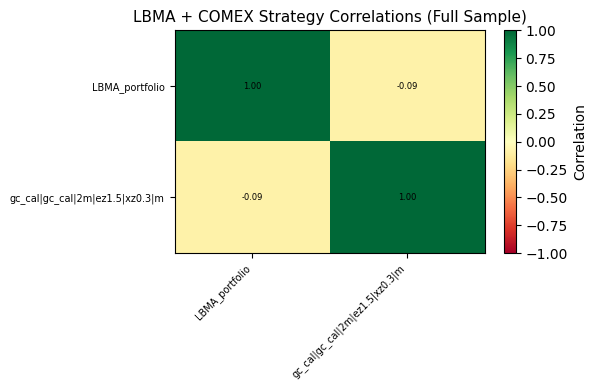

In [18]:
print('Section 6: Building combined LBMA + COMEX portfolio...')

import os

# Try to load LBMA portfolio P&L from saved outputs
LBMA_PNL_FILE = 'outputs/06_portfolio_pnl.csv'
lbma_pnl_df = None

if os.path.exists(LBMA_PNL_FILE):
    _tmp = pd.read_csv(LBMA_PNL_FILE)
    # detect date column
    date_col = [c for c in _tmp.columns if 'date' in c.lower()][0]
    _tmp[date_col] = pd.to_datetime(_tmp[date_col])
    _tmp = _tmp.set_index(date_col)
    # might be single-column (portfolio P&L) — we need per-strategy
    lbma_portfolio_pnl_series = _tmp.iloc[:,0] if _tmp.shape[1] == 1 else _tmp.mean(axis=1)
    print(f"Loaded LBMA portfolio P&L from {LBMA_PNL_FILE}: "
          f"{len(lbma_portfolio_pnl_series)} rows")
else:
    print(f"WARNING: {LBMA_PNL_FILE} not found. Cannot build combined portfolio.")
    lbma_portfolio_pnl_series = None

# Load LBMA strategy-level correlations if available
LBMA_CORR_FILE = 'outputs/05_strategy_correlations.csv'
lbma_strat_pnl = None
if os.path.exists(LBMA_CORR_FILE):
    lbma_corr = pd.read_csv(LBMA_CORR_FILE, index_col=0)
    # The correlation file doesn't have per-strategy P&L
    # We'll use LBMA portfolio as a single block vs COMEX strategies
    print(f"Loaded LBMA correlation matrix: {lbma_corr.shape}")

# ── Combined portfolio ─────────────────────────────────────────────────────
def portfolio_metrics_full(pnl, label):
    if len(pnl) == 0 or pnl.std() == 0:
        return {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan,
                'ann_ret': np.nan, 'p_loss': np.nan}
    cum   = pnl.cumsum()
    dd    = cum - cum.cummax()
    ar    = pnl.mean() * 252
    av    = pnl.std()  * np.sqrt(252)
    sr    = ar / av
    md    = dd.min()
    cal   = ar / abs(md) if md != 0 else np.nan
    # P(annual loss) — approximate from daily distribution
    ann_pnl_sim = [pnl.sample(252, replace=True).sum() for _ in range(1000)]
    p_loss = np.mean(np.array(ann_pnl_sim) < 0) * 100
    return {'sharpe': sr, 'maxdd': md, 'calmar': cal,
            'ann_ret': ar, 'p_loss': p_loss}

results_table = []

# LBMA-only OOS
if lbma_portfolio_pnl_series is not None:
    lbma_oos = lbma_portfolio_pnl_series.loc[
        lbma_portfolio_pnl_series.index >= OOS_START]
    m_lbma = portfolio_metrics_full(lbma_oos, "LBMA only")
    results_table.append({'portfolio': 'LBMA only', **m_lbma})

# COMEX-only OOS
if len(comex_portfolio_pnl) > 0:
    comex_oos = comex_portfolio_pnl.loc[OOS_START:OOS_END]
    m_comex = portfolio_metrics_full(comex_oos, "COMEX only")
    results_table.append({'portfolio': 'COMEX only', **m_comex})

# Combined: LBMA series + COMEX filtered strategies
if lbma_portfolio_pnl_series is not None and len(comex_pnl_filtered) > 0:
    # Align indices
    common_idx = lbma_portfolio_pnl_series.index.intersection(comex_pnl_filtered.index)

    # Build combined pnl matrix: LBMA as single column + COMEX per-strategy
    lbma_col = lbma_portfolio_pnl_series.loc[common_idx].rename('lbma_portfolio')
    combined_mat = pd.concat([lbma_col, comex_pnl_filtered.loc[common_idx]], axis=1).fillna(0)

    # Correlation filter on combined (keep LBMA anchor, then add COMEX if low corr)
    corr_combined = combined_mat.corr()
    combined_keep = ['lbma_portfolio']   # always keep LBMA
    for col in comex_keep:
        if col in corr_combined.columns:
            max_c = corr_combined.loc[col, combined_keep].abs().max()
            if max_c < CORR_THRESHOLD:
                combined_keep.append(col)

    print(f"Combined portfolio: {len(combined_keep)} strategies "
          f"({len(combined_keep)-1} COMEX + 1 LBMA block)")

    comb_mat_filt = combined_mat[combined_keep]
    # Risk-parity weights
    comb_portfolio = pd.Series(0.0, index=comb_mat_filt.index)
    rebal_dates_c  = pd.date_range(
        comb_mat_filt.index[0], comb_mat_filt.index[-1], freq=REBAL_FREQ)
    comb_w = None
    for date in comb_mat_filt.index:
        if comb_w is None or date in rebal_dates_c:
            hist = comb_mat_filt.loc[:date].tail(RISK_PARITY_WINDOW)
            vols = hist.std().replace(0, np.nan)
            comb_w = (1/vols) / (1/vols).sum()
        comb_portfolio.loc[date] = (comb_mat_filt.loc[date] * comb_w).sum()

    comb_oos = comb_portfolio.loc[OOS_START:OOS_END]
    m_comb   = portfolio_metrics_full(comb_oos, "Combined")
    results_table.append({'portfolio': 'Combined', **m_comb})

    # Diversification gain
    if results_table:
        lbma_sr   = next((r['sharpe'] for r in results_table if r['portfolio']=='LBMA only'), np.nan)
        comex_sr  = next((r['sharpe'] for r in results_table if r['portfolio']=='COMEX only'), np.nan)
        comb_sr   = m_comb['sharpe']
        print(f"\nDiversification gain: max(LBMA,COMEX)={max(lbma_sr,comex_sr):.2f}  "
              f"→  Combined={comb_sr:.2f}  "
              f"({'IMPROVED' if comb_sr > max(lbma_sr, comex_sr) else 'NO GAIN'})")

    if SAVE_OUTPUTS:
        comb_portfolio.reset_index().rename(
            columns={0:'pnl_bp','index':'date'}).to_csv(
            f'{OUTPUT_DIR}06_combined_portfolio.csv', index=False)

# Print summary table
print()
print(f"{'Portfolio':<16}  {'OOS SR':>7}  {'Ann P&L':>9}  {'MaxDD':>9}  {'Calmar':>7}  {'P(loss)':>8}")
print('─'*70)
for r in results_table:
    print(f"  {r['portfolio']:<14}  "
          f"{r.get('sharpe',np.nan):>7.2f}  "
          f"{r.get('ann_ret',np.nan):>9.4f}  "
          f"{r.get('maxdd',np.nan):>9.4f}  "
          f"{r.get('calmar',np.nan):>7.2f}  "
          f"{r.get('p_loss',np.nan):>7.1f}%")

# ── Correlation heatmap ─────────────────────────────────────────────────────
if len(comex_pnl_filtered) > 0 and lbma_portfolio_pnl_series is not None:
    common = lbma_portfolio_pnl_series.index.intersection(comex_pnl_filtered.index)
    heat_df = pd.concat([
        lbma_portfolio_pnl_series.loc[common].rename('LBMA_portfolio'),
        comex_pnl_filtered.loc[common, comex_keep]
    ], axis=1).fillna(0)

    fig, ax = plt.subplots(figsize=(max(6, len(heat_df.columns)), max(4, len(heat_df.columns)//2)))
    corr_h = heat_df.corr()
    im = ax.imshow(corr_h.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr_h.columns)))
    ax.set_yticks(range(len(corr_h.columns)))
    labs = [c[:30] for c in corr_h.columns]
    ax.set_xticklabels(labs, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(labs, fontsize=7)
    for i in range(len(corr_h)):
        for j in range(len(corr_h.columns)):
            ax.text(j, i, f'{corr_h.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
    plt.colorbar(im, ax=ax, label='Correlation')
    ax.set_title('LBMA + COMEX Strategy Correlations (Full Sample)', fontsize=11)
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(f'{OUTPUT_DIR}06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()


# 7. Attribution & Regime Analysis

Section 7: Attribution and regime analysis...

P&L attribution by block (OOS):
       oos_total_bp
block              
A_cal     20.784502


Trade statistics per strategy (OOS):
Strategy                                                 Trades    Hit%      AvgW      AvgL      PF
───────────────────────────────────────────────────────────────────────────────────────────────
  gc_cal|gc_cal|2m|ez1.5|xz0.3|mh20|cb0.08                   22   72.7%     1.665    -0.976    4.55


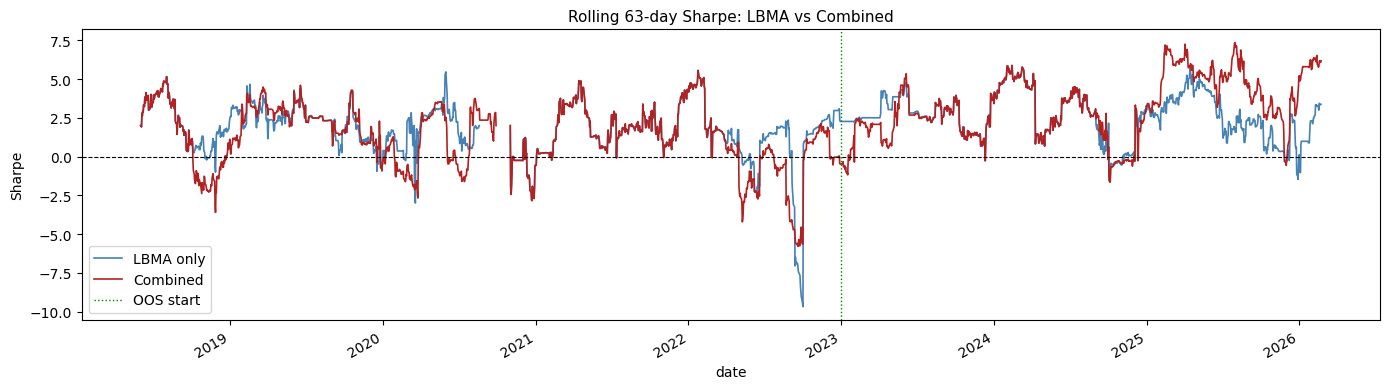


Worst 10 LBMA days (OOS) — COMEX P&L on same day:
  Date            LBMA P&L    COMEX P&L  Hedge?
  ──────────────────────────────────────────────────
  2024-10-03       -1.0497       0.0073  YES ✓
  2025-10-08       -0.6577       0.0000  NO
  2023-10-11       -0.3713       0.0000  NO
  2023-10-23       -0.3167       0.0000  NO
  2025-08-22       -0.3071      -0.2929  NO
  2025-10-02       -0.3035       0.0000  NO
  2025-03-05       -0.3007       0.0000  NO
  2025-02-17       -0.2901       0.0000  NO
  2025-04-23       -0.2589       0.0000  NO
  2025-08-13       -0.2466       0.0000  NO


In [19]:
print('Section 7: Attribution and regime analysis...')

if len(comex_keep) == 0:
    print("No COMEX strategies — skipping attribution.")
else:
    # ── 7.1  P&L by block ────────────────────────────────────────────────
    block_map = {
        'gc_comex_carry_2m':      'A_cal',
        'gc_comex_carry_4m':      'A_cal',
        'si_comex_carry_2m':      'A_cal',
        'gc_cal_curvature':       'A_cal',
        'gc_si_cal_ratio':        'A_cal',
        'gc_comex_lbma_basis':    'B_basis',
        'si_comex_lbma_basis':    'B_basis',
        'gc_si_comex_basis_spread':'B_basis',
        'efp_xau_bp':             'C_efp',
        'efp_xag_bp':             'C_efp',
        'efp_xau_xag_diff':       'C_efp',
        'gc_comex_curve_slope':   'D_slope',
        'comex_lbma_slope_basis': 'D_slope',
    }

    attrib_rows = []
    for key in comex_keep:
        parts = key.split('|')
        feat_col = None
        for col in comex_features:
            test_key = (f"{FTYPE_MAP.get(col,('unk','unk','unk'))[1]}|"
                        f"{FTYPE_MAP.get(col,('unk','unk','unk'))[0]}|"
                        f"{FTYPE_MAP.get(col,('unk','unk','unk'))[2]}")
            if parts[0] == FTYPE_MAP.get(col,('unk','unk','unk'))[1] and                parts[1] == FTYPE_MAP.get(col,('unk','unk','unk'))[0]:
                feat_col = col; break
        if feat_col is None:
            # fallback: match by bucket
            for col in comex_features:
                if FTYPE_MAP.get(col,('','',''))[2] == parts[2]:
                    feat_col = col; break
        if feat_col is None: continue

        daily_pnl = comex_candidate_daily.get(key)
        if daily_pnl is None: continue

        oos_pnl = daily_pnl.loc[OOS_START:OOS_END]
        block   = block_map.get(feat_col, 'other')
        attrib_rows.append({
            'key': key, 'feature': feat_col, 'block': block,
            'oos_total_bp': oos_pnl.sum(),
            'oos_sharpe':   oos_pnl.mean()*252/(oos_pnl.std()*np.sqrt(252))
                            if oos_pnl.std() > 0 else np.nan,
            'oos_trades':   int((oos_pnl != 0).sum() // 20),  # rough estimate
        })

    if attrib_rows:
        attrib_df = pd.DataFrame(attrib_rows)
        print("\nP&L attribution by block (OOS):")
        print(attrib_df.groupby('block')[['oos_total_bp']].sum().to_string())
        if SAVE_OUTPUTS:
            attrib_df.to_csv(f'{OUTPUT_DIR}07_attribution.csv', index=False)

    # ── 7.2  Trade-level statistics ───────────────────────────────────────
    print("\n\nTrade statistics per strategy (OOS):")
    print(f"{'Strategy':<55}  {'Trades':>6}  {'Hit%':>6}  {'AvgW':>8}  {'AvgL':>8}  {'PF':>6}")
    print('─' * 95)
    for key in comex_keep:
        row_match = comex_selected[comex_selected.apply(
            lambda r: (f"{r['metal']}|{r['feature_type']}|{r['bucket']}|"
                       f"ez{r['entry_z']}|xz{r['exit_z']}|"
                       f"mh{int(r['max_hold'])}|cb{r['cost_bp']}") == key, axis=1)]
        if not len(row_match): continue
        row = row_match.iloc[0]
        r = backtest_single(df.loc[OOS_START:OOS_END], row['signal_col'],
                            row['feature_col'], entry_z=row['entry_z'],
                            exit_z=row['exit_z'], stop_z=STOP_Z,
                            max_hold=int(row['max_hold']), cost_bp=row['cost_bp'])
        tl = r['trade_log']
        if len(tl) == 0: continue
        wins  = tl[tl['pnl_bp'] > 0]['pnl_bp']
        losses= tl[tl['pnl_bp'] <= 0]['pnl_bp']
        hit   = len(wins) / len(tl) * 100
        aw    = wins.mean()  if len(wins)   else 0
        al    = losses.mean()if len(losses) else 0
        pf    = abs(aw*len(wins)) / abs(al*len(losses)) if len(losses) and al != 0 else np.nan
        print(f"  {key[:53]:<53}  {len(tl):>6d}  {hit:>5.1f}%  "
              f"{aw:>8.3f}  {al:>8.3f}  {pf:>6.2f}")

    # ── 7.3  Rolling Sharpe: LBMA vs Combined ─────────────────────────────
    if lbma_portfolio_pnl_series is not None and 'comb_portfolio' in dir():
        fig, ax = plt.subplots(figsize=(14, 4))
        roll_sr_lbma = (lbma_portfolio_pnl_series.rolling(63).mean() * 252 /
                        (lbma_portfolio_pnl_series.rolling(63).std() * np.sqrt(252)))
        roll_sr_comb = (comb_portfolio.rolling(63).mean() * 252 /
                        (comb_portfolio.rolling(63).std() * np.sqrt(252)))
        roll_sr_lbma.plot(ax=ax, label='LBMA only', lw=1.2, color='steelblue')
        roll_sr_comb.plot(ax=ax, label='Combined',  lw=1.2, color='firebrick')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.axvline(pd.Timestamp(OOS_START), color='green', lw=1, ls=':', label='OOS start')
        ax.set_title('Rolling 63-day Sharpe: LBMA vs Combined', fontsize=11)
        ax.legend(); ax.set_ylabel('Sharpe')
        plt.tight_layout()
        if SAVE_OUTPUTS:
            plt.savefig(f'{OUTPUT_DIR}07_rolling_sharpe.png', dpi=120, bbox_inches='tight')
        plt.show()

    # ── 7.4  Worst LBMA days — did COMEX hedge? ───────────────────────────
    if lbma_portfolio_pnl_series is not None and len(comex_portfolio_pnl) > 0:
        common_oos = lbma_portfolio_pnl_series.loc[OOS_START:].index.intersection(
            comex_portfolio_pnl.loc[OOS_START:].index)
        worst10 = lbma_portfolio_pnl_series.loc[common_oos].nsmallest(10)
        print("\nWorst 10 LBMA days (OOS) — COMEX P&L on same day:")
        print(f"  {'Date':<12}  {'LBMA P&L':>10}  {'COMEX P&L':>11}  {'Hedge?'}")
        print('  ' + '─'*50)
        for dt, lv in worst10.items():
            cv = comex_portfolio_pnl.get(dt, np.nan) if dt in comex_portfolio_pnl.index else np.nan
            hedge = 'YES ✓' if (not np.isnan(cv) and cv > 0) else ('NO' if not np.isnan(cv) else '-')
            print(f"  {str(dt.date()):<12}  {lv:>10.4f}  {cv:>11.4f}  {hedge}")


# 8. Daily Signal Integration

Blotter-compatible with `silver_gold_lease_curve_v2.ipynb` Section 10c.

In [20]:
print('Section 8: Daily signal integration (blotter-compatible)...')

TENOR_DAYS_MAP = {'1m': 30, '3m': 91, '6m': 182, '9m': 273, '1y': 365, '2y': 730}
CURRENT_SPOT_XAU = df['xauusd_spot'].iloc[-1] if 'xauusd_spot' in df.columns else 2900.0
CURRENT_SPOT_XAG = df['xagusd_spot'].iloc[-1] if 'xagusd_spot' in df.columns else 30.0

def comex_map_to_instrument(feature_col, state, oz=1.0, spot=2900.0):
    """Map COMEX feature to blotter instrument description."""
    contracts = max(1, round(oz / 100))  # 1 GC contract = 100 oz

    if feature_col in ('gc_comex_carry_2m',):
        instrument = 'COMEX GC Calendar Spread \u2014 Front/Second'
        if state == 1:
            leg1 = f'BUY  GC front (go long nearby, +{contracts} contracts)'
            leg2 = f'SELL GC second (short deferred, -{contracts} contracts)'
            desc = 'Long GC calendar spread: buy nearby / sell deferred'
        else:
            leg1 = f'SELL GC front (short nearby, -{contracts} contracts)'
            leg2 = f'BUY  GC second (long deferred, +{contracts} contracts)'
            desc = 'Short GC calendar spread: sell nearby / buy deferred'
        dv01 = oz * spot * (GC_DAYS_12 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': 'CME electronic execution; tight bid/ask on calendar spread'}

    elif feature_col == 'gc_comex_carry_4m':
        instrument = 'COMEX GC Calendar Spread \u2014 Front/Third'
        if state == 1:
            leg1 = f'BUY  GC front (+{contracts} contracts)'
            leg2 = f'SELL GC third (-{contracts} contracts)'
            desc = 'Long GC 1/3 calendar: buy front / sell 3rd contract'
        else:
            leg1 = f'SELL GC front (-{contracts} contracts)'
            leg2 = f'BUY  GC third (+{contracts} contracts)'
            desc = 'Short GC 1/3 calendar: sell front / buy 3rd contract'
        dv01 = oz * spot * (GC_DAYS_13 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': 'CME electronic execution; wider spread than 1/2 calendar'}

    elif feature_col == 'si_comex_carry_2m':
        instrument = 'COMEX SI Calendar Spread \u2014 Front/Second'
        if state == 1:
            leg1 = f'BUY  SI front (+{contracts * 50} contracts @5000oz ea)'
            leg2 = f'SELL SI second (-{contracts * 50} contracts)'
            desc = 'Long SI calendar spread'
        else:
            leg1 = f'SELL SI front'
            leg2 = f'BUY  SI second'
            desc = 'Short SI calendar spread'
        dv01 = oz * CURRENT_SPOT_XAG * (SI_DAYS_12 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '1 SI contract = 5,000 troy oz; adjust contract count accordingly'}

    elif feature_col in ('gc_comex_lbma_basis', 'si_comex_lbma_basis',
                          'gc_si_comex_basis_spread', 'comex_lbma_slope_basis'):
        metal = 'GC/XAU' if 'gc' in feature_col or 'xau' in feature_col else 'SI/XAG'
        instrument = f'{metal} COMEX/LBMA Carry Basis'
        if state == 1:
            leg1 = f'BUY  {metal.split("/")[0]} calendar spread (COMEX futures)'
            leg2 = f'PAY  fixed {metal.split("/")[1]} swap 2m (LBMA OTC)'
            desc = f'Long {metal} COMEX/LBMA basis: COMEX cheap vs LBMA'
        else:
            leg1 = f'SELL {metal.split("/")[0]} calendar spread (COMEX futures)'
            leg2 = f'RECEIVE fixed {metal.split("/")[1]} swap 2m (LBMA OTC)'
            desc = f'Short {metal} COMEX/LBMA basis: COMEX rich vs LBMA'
        dv01 = oz * spot * (61 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** CROSS-VENUE: requires simultaneous COMEX futures + LBMA OTC swap execution. Alert dealer before entry.'}

    elif feature_col in ('efp_xau_bp', 'efp_xau_xag_diff'):
        instrument = 'XAU Exchange for Physical (EFP)'
        if state == 1:
            leg1 = f'SELL GC front (futures, -{contracts} contracts)'
            leg2 = f'BUY  XAU spot (physical, +{oz:,.0f} oz)'
            desc = 'Long EFP: sell futures / buy spot (futures rich vs spot)'
        else:
            leg1 = f'BUY  GC front (futures, +{contracts} contracts)'
            leg2 = f'SELL XAU spot (physical, -{oz:,.0f} oz)'
            desc = 'Short EFP: buy futures / sell spot (futures cheap vs spot)'
        dv01 = oz * spot * (EFP_DAYS / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** EFP: execute via LBMA member dealer. Must notify CME within 15 min of execution.'}

    elif feature_col == 'efp_xag_bp':
        instrument = 'XAG Exchange for Physical (EFP)'
        if state == 1:
            leg1 = 'SELL SI front (futures)'
            leg2 = 'BUY  XAG spot (physical)'
            desc = 'Long XAG EFP: sell futures / buy spot'
        else:
            leg1 = 'BUY  SI front (futures)'
            leg2 = 'SELL XAG spot (physical)'
            desc = 'Short XAG EFP: buy futures / sell spot'
        dv01 = oz * CURRENT_SPOT_XAG * (EFP_DAYS / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** EFP: execute via LBMA member dealer. Must notify CME within 15 min.'}

    else:  # generic
        return {'instrument': feature_col, 'leg1': '-', 'leg2': '-', 'leg3': '-',
                'direction_desc': '-', 'contracts': 1, 'dv01_gross': 0, 'dv01_net': 0,
                'note': ''}


# ── Build today's blotter ────────────────────────────────────────────────
today      = df.index[-1]
blotter_rows = []

for col in comex_features:
    zcol = f'z_{col}'
    if zcol not in df.columns: continue

    z_today = df[zcol].iloc[-1]
    z_prev  = df[zcol].iloc[-2] if len(df) > 1 else np.nan
    f_today = df[col].iloc[-1]
    f_mean  = df[col].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean().iloc[-1]

    ez = 1.5  # default entry threshold (best param from sweep if available)
    if len(comex_keep) > 0:
        key_match = [k for k in comex_keep if col in k]
        if key_match:
            # extract entry_z from key string
            for seg in key_match[0].split('|'):
                if seg.startswith('ez'):
                    try: ez = float(seg[2:]); break
                    except: pass

    if abs(z_today) >= ez:
        signal    = 'ENTRY SIGNAL'
        direction = 'LONG' if z_today < 0 else 'SHORT'
    elif abs(z_today) >= ez * 0.80:
        signal    = 'APPROACHING'
        direction = 'LONG' if z_today < 0 else 'SHORT'
    else:
        signal    = 'watch'
        direction = '-'

    state = -1 if direction == 'SHORT' else (1 if direction == 'LONG' else 0)
    instr = comex_map_to_instrument(col, state, oz=100, spot=CURRENT_SPOT_XAU)

    blotter_rows.append({
        'date': today.date(), 'feature': col, 'z_score': round(z_today, 3),
        'z_1d_chg': round(z_today - z_prev, 3) if not np.isnan(z_prev) else np.nan,
        'raw_value': round(f_today, 4), 'mean_252d': round(f_mean, 4),
        'direction': direction, 'signal': signal, 'entry_z': ez,
        'instrument': instr['instrument'], 'description': instr['direction_desc'],
        'leg1': instr['leg1'], 'leg2': instr['leg2'],
        'contracts': instr.get('contracts', 1),
        'dv01_gross': round(instr.get('dv01_gross', 0), 2),
        'note': instr.get('note', ''),
    })

blotter_df = pd.DataFrame(blotter_rows)

# Print blotter
print(f"\n{'='*78}")
print(f"  COMEX SIGNAL BLOTTER  --  {today.date()}")
print(f"  XAU spot: ${CURRENT_SPOT_XAU:,.0f}  |  XAG spot: ${CURRENT_SPOT_XAG:.2f}")
print(f"{'='*78}")

active   = blotter_df[blotter_df['signal'] == 'ENTRY SIGNAL']
watching = blotter_df[blotter_df['signal'] == 'APPROACHING']
quiet    = blotter_df[blotter_df['signal'] == 'watch']

if len(active) > 0:
    print(f"\n*** ACTIVE SIGNALS ({len(active)}) ***")
    for _, r in active.iterrows():
        print(f"\n  [ENTRY] {r['feature']:<32}  z={r['z_score']:+.3f}  dz={r['z_1d_chg']:+.3f}")
        print(f"  {'─'*65}")
        print(f"  Instrument : {r['instrument']}")
        print(f"  Direction  : {r['description']}")
        print(f"  Leg 1 \u2192 {r['leg1']}")
        print(f"  Leg 2 \u2192 {r['leg2']}")
        print(f"  Raw value  : {r['raw_value']:.4f}%  |  252d mean: {r['mean_252d']:.4f}%")
        print(f"  DV01       : ${r['dv01_gross']:,.2f} (per 1bp, {r['contracts']} contracts)")
        if r['note']:
            print(f"  NOTE       : {r['note']}")
else:
    print("\n  No active entry signals.")

if len(watching) > 0:
    print(f"\n--- APPROACHING ({len(watching)}) ---")
    for _, r in watching.iterrows():
        print(f"  [WATCH]  {r['feature']:<32}  z={r['z_score']:+.3f}  "
              f"({r['direction']})  raw={r['raw_value']:.4f}%")

print(f"\n--- MONITORING ({len(quiet)}) ---")
for _, r in quiet.iterrows():
    print(f"  {r['feature']:<32}  z={r['z_score']:+.3f}  signal={r['signal']}")

print(f"\n{'='*78}")

if SAVE_OUTPUTS:
    blotter_df.to_csv(f'{OUTPUT_DIR}08_daily_blotter.csv', index=False)
    print(f"Saved: {OUTPUT_DIR}08_daily_blotter.csv")


Section 8: Daily signal integration (blotter-compatible)...

  COMEX SIGNAL BLOTTER  --  2026-02-27
  XAU spot: $5,279  |  XAG spot: $93.79

*** ACTIVE SIGNALS (2) ***

  [ENTRY] si_comex_carry_2m                 z=-1.791  dz=-0.070
  ─────────────────────────────────────────────────────────────────
  Instrument : COMEX SI Calendar Spread — Front/Second
  Direction  : Long SI calendar spread
  Leg 1 → BUY  SI front (+50 contracts @5000oz ea)
  Leg 2 → SELL SI second (-50 contracts)
  Raw value  : 3.8779%  |  252d mean: 6.1916%
  DV01       : $0.16 (per 1bp, 1 contracts)
  NOTE       : 1 SI contract = 5,000 troy oz; adjust contract count accordingly

  [ENTRY] gc_si_cal_ratio                   z=+2.046  dz=+0.136
  ─────────────────────────────────────────────────────────────────
  Instrument : gc_si_cal_ratio
  Direction  : -
  Leg 1 → -
  Leg 2 → -
  Raw value  : 1.1903%  |  252d mean: 0.8162%
  DV01       : $0.00 (per 1bp, 1 contracts)

--- MONITORING (11) ---
  gc_comex_carry_2m    

# 9. Bloomberg Data Pull Spec

BQL queries for production COMEX data feed.

In [21]:
print('Section 9: Bloomberg COMEX data pull specification')
print()

GC_FUTURES_FIELDS = {
    'gc_fut_front':  'GC1 COMDTY PX_LAST',
    'gc_fut_second': 'GC2 COMDTY PX_LAST',
    'gc_fut_third':  'GC3 COMDTY PX_LAST',
    'gc_expiry_1':   'GC1 COMDTY LAST_TRADEABLE_DT',   # for exact DTE
    'gc_expiry_2':   'GC2 COMDTY LAST_TRADEABLE_DT',
    'gc_expiry_3':   'GC3 COMDTY LAST_TRADEABLE_DT',
}
SI_FUTURES_FIELDS = {
    'si_fut_front':  'SI1 COMDTY PX_LAST',
    'si_fut_second': 'SI2 COMDTY PX_LAST',
    'si_fut_third':  'SI3 COMDTY PX_LAST',
    'si_expiry_1':   'SI1 COMDTY LAST_TRADEABLE_DT',
    'si_expiry_2':   'SI2 COMDTY LAST_TRADEABLE_DT',
}
EFP_SPOT_FIELDS = {
    'xauusd_spot':   'XAU CURNCY PX_LAST',
    'xagusd_spot':   'XAG CURNCY PX_LAST',
    'lbma_gold_am':  'GOLDLNAM INDEX PX_LAST',
    'lbma_gold_pm':  'GOLDLNPM INDEX PX_LAST',
}

print("# ─── Required Bloomberg fields for COMEX expansion ───────────────────")
print("# Pull daily using BQL or Bloomberg API (supplement to LBMA notebook pull)")
print()
print("GC_FUTURES_FIELDS =", GC_FUTURES_FIELDS)
print()
print("SI_FUTURES_FIELDS =", SI_FUTURES_FIELDS)
print()
print("EFP_SPOT_FIELDS =",   EFP_SPOT_FIELDS)
print()
print("# NOTE: gc_expiry_1/2/3 allow computation of EXACT days-to-expiry")
print("# for DV01 and annualised carry, replacing the 61-day approximation.")
print("# Update GC_CALENDAR_DAYS dynamically from expiry dates in production:")
print("#")
print("#   from datetime import date")
print("#   gc_days_12 = (gc_expiry_2 - gc_expiry_1).days")
print("#   gc_days_13 = (gc_expiry_3 - gc_expiry_1).days")
print("#   CONFIG['GC_CALENDAR_DAYS'] = {'1_2': gc_days_12, '1_3': gc_days_13}")
print()
print("# ─── BQL template (BQNT) ────────────────────────────────────────────")
print('''
# import bql
# bq = bql.Service()
# universe = bq.univ.list(['GC1 COMDTY','GC2 COMDTY','GC3 COMDTY',
#                           'SI1 COMDTY','SI2 COMDTY',
#                           'XAU CURNCY','XAG CURNCY',
#                           'GOLDLNAM INDEX','GOLDLNPM INDEX'])
# item = bq.data.px_last(dates=bq.func.range(start_date, end_date),
#                         frq='D', fill='prev')
# response = bq.execute(bql.Request(universe, item))
# df_bbg = response[0].df().pivot(columns='ID', values='PX_LAST')
# rename columns to match DATA_FILE column names above
''')
print("Section 9 complete.")


Section 9: Bloomberg COMEX data pull specification

# ─── Required Bloomberg fields for COMEX expansion ───────────────────
# Pull daily using BQL or Bloomberg API (supplement to LBMA notebook pull)

GC_FUTURES_FIELDS = {'gc_fut_front': 'GC1 COMDTY PX_LAST', 'gc_fut_second': 'GC2 COMDTY PX_LAST', 'gc_fut_third': 'GC3 COMDTY PX_LAST', 'gc_expiry_1': 'GC1 COMDTY LAST_TRADEABLE_DT', 'gc_expiry_2': 'GC2 COMDTY LAST_TRADEABLE_DT', 'gc_expiry_3': 'GC3 COMDTY LAST_TRADEABLE_DT'}

SI_FUTURES_FIELDS = {'si_fut_front': 'SI1 COMDTY PX_LAST', 'si_fut_second': 'SI2 COMDTY PX_LAST', 'si_fut_third': 'SI3 COMDTY PX_LAST', 'si_expiry_1': 'SI1 COMDTY LAST_TRADEABLE_DT', 'si_expiry_2': 'SI2 COMDTY LAST_TRADEABLE_DT'}

EFP_SPOT_FIELDS = {'xauusd_spot': 'XAU CURNCY PX_LAST', 'xagusd_spot': 'XAG CURNCY PX_LAST', 'lbma_gold_am': 'GOLDLNAM INDEX PX_LAST', 'lbma_gold_pm': 'GOLDLNPM INDEX PX_LAST'}

# NOTE: gc_expiry_1/2/3 allow computation of EXACT days-to-expiry
# for DV01 and annualised carry, replacing the 

# 10. Stress Test — EFP Strategy Across Market Crises

Tests `backtest_efp()` over four named stress windows with granular per-window
metrics: cumulative P&L, max drawdown, trade count, stop-loss rate, carry vs
basis decomposition, and stop-loss sensitivity grid.

STRESS TEST REPORT — EFP STRATEGY (ez=1.5, xz=0.5, stopz=3.5)
Window                                        Metal    TotPL    MaxDD    N  Long  Short  Stops  %Stop   WinR   WinL   WinS    AvgPL   AvgBas   AvgCry  AvgHld
------------------------------------------------------------------------------------------------------------------------
COVID EFP Blowout                             XAU    NO DATA
CME-LBMA Basis Crisis                         XAU    NO DATA
Trump Tariff XAG Shock                        XAU    NO DATA
XAU/XAG Lease Blowout                         XAU     +180.7    -13.7    3     2      1      0   0.0%  66.7%  50.0% 100.0%   +24.89   +29.53    -4.40    6.0d

COVID EFP Blowout                             XAG    NO DATA
CME-LBMA Basis Crisis                         XAG    NO DATA
Trump Tariff XAG Shock                        XAG    NO DATA
XAU/XAG Lease Blowout                         XAG     +242.4    -25.8    5     0      5      0   0.0%  40.0%    nan  40.0%   +48.61   

XAU   $   30 XAU/XAG Lease Blowout                 +180.7    -13.7    3      0   0.0%  66.7%

XAG   $   10 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%
XAG   $   12 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%
XAG   $   15 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%


XAG   $   18 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%
XAG   $   22 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%
XAG   $   30 XAU/XAG Lease Blowout                 +242.4    -25.8    5      0   0.0%  40.0%


WORST 5 TRADES PER STRESS WINDOW (XAU + XAG COMBINED)

  ▶  COVID EFP Blowout  (2020-02-15 → 2020-06-30)
     No trades in this window.

  ▶  CME-LBMA Basis Crisis  (2024-10-01 → 2025-03-01)
     No trades in this window.

  ▶  Trump Tariff XAG Shock  (2025-02-01 → 2025-04-30)
     No trades in this window.

  ▶  XAU/XAG Lease Blowout  (2025-09-01 → 2025-11-30)
  Mtl   Direction           Entry         Exit  Hold    TotPL    Basis    Carry  EntryZ   ExitZ Reason
  ----------------------------------------------------------------------------------------------------
  XAU   LONG EFP       2025-11-14   2025-11-25    11d   -13.75    -1.36   -12.15   +4.30 USD   +4.86 USD fnd_exit
  XAG   SHORT EFP      2025-10-17  

Chart saved → outputs_comex/stress_test_efp.png


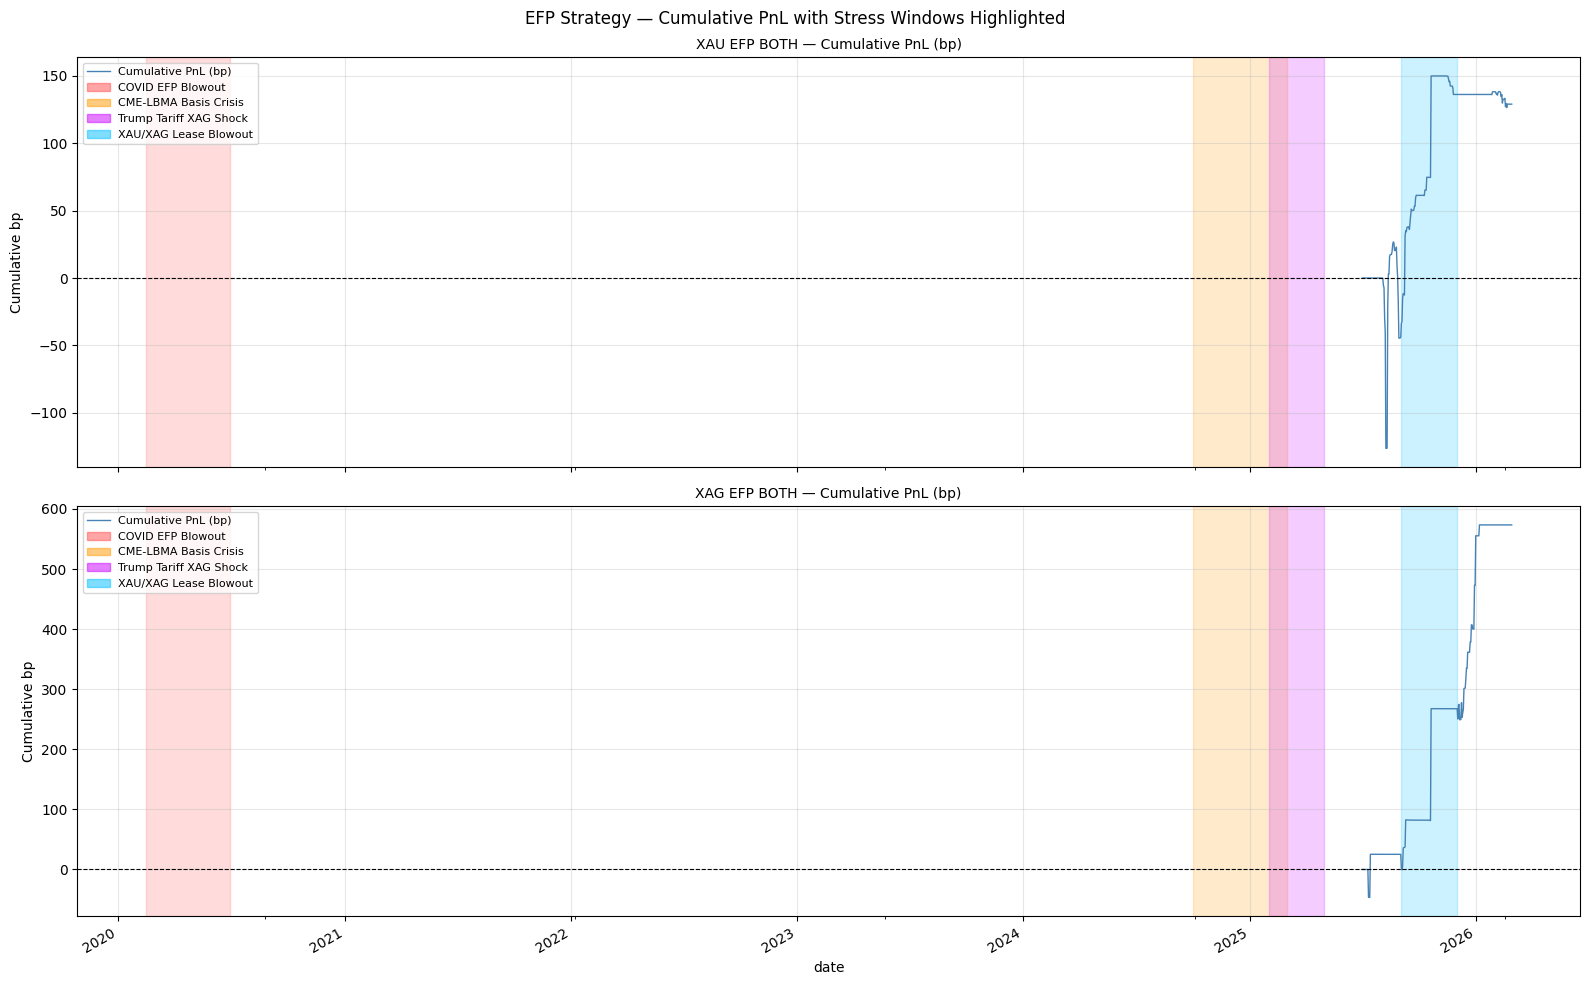


✓ Stress test complete.

✓ Stress slippage analysis complete. (slippage section skipped)


In [22]:
###############################################################################
# SECTION: STRESS TEST — EFP STRATEGY ACROSS FOUR MARKET CRISES
###############################################################################

import matplotlib.patches as mpatches

# ── 1. STRESS WINDOWS ────────────────────────────────────────────────────────
STRESS_WINDOWS = {
    "COVID EFP Blowout":        ("2020-02-15", "2020-06-30"),
    "CME-LBMA Basis Crisis":    ("2024-10-01", "2025-03-01"),
    "Trump Tariff XAG Shock":   ("2025-02-01", "2025-04-30"),
    "XAU/XAG Lease Blowout":    ("2025-09-01", "2025-11-30"),
}

# ── 2. BEST CONFIG FROM SECTION 3C ───────────────────────────────────────────
BEST_PARAMS = dict(
    entry_usd_long=CONFIG['EFP_ENTRY_USD_LONG'],
    entry_usd_short=_short_entry_xau,   # XAU p25; overridden per-metal below
    exit_usd=CONFIG['EFP_EXIT_USD'],
    stop_usd_short=CONFIG['EFP_STOP_USD_SHORT'],
    exec_cost_bp=CONFIG['EFP_EXEC_COST_BP'],
    long_enabled=True,
    short_enabled=True,
    is_cutoff=None,
)

METALS = ['xau', 'xag']

# ── 3. HELPER: PER-WINDOW METRICS ────────────────────────────────────────────
def stress_metrics(daily_pnl, trade_log, window_start, window_end):
    mask_d = (daily_pnl.index >= window_start) & (daily_pnl.index <= window_end)
    mask_t = (trade_log['entry_date'] >= pd.Timestamp(window_start)) & \
             (trade_log['entry_date'] <= pd.Timestamp(window_end))
    dpnl = daily_pnl[mask_d]
    tlog = trade_log[mask_t]

    if len(dpnl) == 0 or dpnl.std() == 0:
        return None

    cum       = dpnl.cumsum()
    maxdd     = (cum - cum.cummax()).min()
    total_pnl = cum.iloc[-1]

    if len(tlog) == 0:
        return dict(
            total_pnl_bp=total_pnl, max_dd_bp=maxdd,
            n_trades=0, n_long=0, n_short=0,
            n_stops=0, pct_stops=np.nan,
            n_fnd=0, n_revert=0, win_rate=np.nan,
            win_rate_long=np.nan, win_rate_short=np.nan,
            avg_total_bp=np.nan, avg_basis_bp=np.nan,
            avg_carry_bp=np.nan, avg_carry_long=np.nan,
            avg_carry_short=np.nan, avg_hold_days=np.nan,
        )

    n_trades = len(tlog)
    n_stops  = (tlog['exit_reason'] == 'stop_loss').sum()
    n_fnd    = (tlog['exit_reason'] == 'fnd_exit').sum()
    n_revert = (tlog['exit_reason'] == 'z_revert').sum()
    lt = tlog[tlog['state'] ==  1]
    st = tlog[tlog['state'] == -1]

    return dict(
        total_pnl_bp  = total_pnl,
        max_dd_bp     = maxdd,
        n_trades      = n_trades,
        n_long        = len(lt),
        n_short       = len(st),
        n_stops       = n_stops,
        pct_stops     = n_stops / n_trades * 100,
        n_fnd         = n_fnd,
        n_revert      = n_revert,
        win_rate      = (tlog['total_pnl_bp'] > 0).mean() * 100,
        win_rate_long = (lt['total_pnl_bp'] > 0).mean() * 100 if len(lt) else np.nan,
        win_rate_short= (st['total_pnl_bp'] > 0).mean() * 100 if len(st) else np.nan,
        avg_total_bp  = tlog['total_pnl_bp'].mean(),
        avg_basis_bp  = tlog['basis_pnl_bp'].mean(),
        avg_carry_bp  = tlog['carry_pnl_bp'].mean(),
        avg_carry_long= lt['carry_pnl_bp'].mean() if len(lt) else np.nan,
        avg_carry_short= st['carry_pnl_bp'].mean() if len(st) else np.nan,
        avg_hold_days = tlog['hold_days'].mean(),
    )

# ── 4. RUN FULL BACKTEST ONCE PER METAL ──────────────────────────────────────
cached = {}
for metal in METALS:
    r = backtest_efp(df_efp, metal=metal, **{
            **BEST_PARAMS,
            'entry_usd_short': _short_entry_xau if metal=='xau' else _short_entry_xag,
        })
    if r is None:
        print(f"[{metal.upper()}] backtest_efp returned None — check data.")
    else:
        cached[metal] = r

# ── 5. SUMMARY REPORT ────────────────────────────────────────────────────────
print("=" * 120)
print("STRESS TEST REPORT — EFP STRATEGY (ez=1.5, xz=0.5, stopz=3.5)")
print("=" * 120)
hdr = (f"{'Window':<45} {'Metal':<5} {'TotPL':>8} {'MaxDD':>8} {'N':>4} "
       f"{'Long':>5} {'Short':>6} {'Stops':>6} {'%Stop':>6} "
       f"{'WinR':>6} {'WinL':>6} {'WinS':>6} "
       f"{'AvgPL':>8} {'AvgBas':>8} {'AvgCry':>8} {'AvgHld':>7}")
print(hdr)
print("-" * 120)

all_results = {}
for metal in METALS:
    if metal not in cached:
        continue
    r = cached[metal]
    for window_name, (ws, we) in STRESS_WINDOWS.items():
        m = stress_metrics(r['daily_pnl'], r['trade_log'], ws, we)
        all_results[(metal, window_name)] = m
        if m is None:
            print(f"{window_name:<45} {metal.upper():<5}  NO DATA")
            continue
        nt = m['n_trades']
        print(
            f"{window_name:<45} {metal.upper():<5} "
            f"{m['total_pnl_bp']:>+8.1f} "
            f"{m['max_dd_bp']:>+8.1f} "
            f"{nt:>4d} "
            f"{m['n_long']:>5d} "
            f"{m['n_short']:>6d} "
            f"{m['n_stops']:>6d} "
            f"{'nan' if np.isnan(m['pct_stops']) else f"{m['pct_stops']:>5.1f}%":>6} "
            f"{'nan' if np.isnan(m['win_rate']) else f"{m['win_rate']:>5.1f}%":>6} "
            f"{'nan' if np.isnan(m['win_rate_long']) else f"{m['win_rate_long']:>5.1f}%":>6} "
            f"{'nan' if np.isnan(m['win_rate_short']) else f"{m['win_rate_short']:>5.1f}%":>6} "
            f"{'nan' if np.isnan(m['avg_total_bp']) else f"{m['avg_total_bp']:>+8.2f}":>8} "
            f"{'nan' if np.isnan(m['avg_basis_bp']) else f"{m['avg_basis_bp']:>+8.2f}":>8} "
            f"{'nan' if np.isnan(m['avg_carry_bp']) else f"{m['avg_carry_bp']:>+8.2f}":>8} "
            f"{'nan' if np.isnan(m['avg_hold_days']) else f"{m['avg_hold_days']:>6.1f}d":>7}"
        )
    print()

# ── 6. STOP-LOSS SENSITIVITY ─────────────────────────────────────────────────
print("\n" + "=" * 100)
print("STOP-LOSS SENSITIVITY — stop_usd_short tested at [10, 12, 15, 18, 22, 30] USD/oz")
print("=" * 100)
STOPZ_GRID = [10.0, 12.0, 15.0, 18.0, 22.0, 30.0]   # USD/oz stop

print(f"\n{'Metal':<5} {'StopZ':>6} {'Window':<35} "
      f"{'TotPL':>8} {'MaxDD':>8} {'N':>4} {'Stops':>6} {'%Stop':>6} {'WinR':>6}")
print("-" * 100)

for metal in METALS:
    for stopz_val in STOPZ_GRID:
        _sxau = _short_entry_xau if metal=='xau' else _short_entry_xag
        r = backtest_efp(df_efp, metal=metal, **{**BEST_PARAMS,
            'entry_usd_short': _sxau, 'stop_usd_short': stopz_val})
        if r is None:
            continue
        for window_name, (ws, we) in STRESS_WINDOWS.items():
            m = stress_metrics(r['daily_pnl'], r['trade_log'], ws, we)
            if m and m['n_trades'] > 0:
                pct_s = f"{m['pct_stops']:>5.1f}%" if not np.isnan(m['pct_stops']) else "   nan"
                wr    = f"{m['win_rate']:>5.1f}%"  if not np.isnan(m['win_rate'])   else "   nan"
                print(
                    f"{metal.upper():<5} ${stopz_val:>5.0f} {window_name:<35} "
                    f"{m['total_pnl_bp']:>+8.1f} "
                    f"{m['max_dd_bp']:>+8.1f} "
                    f"{m['n_trades']:>4d} "
                    f"{m['n_stops']:>6d} "
                    f"{pct_s:>6} "
                    f"{wr:>6}"
                )
    print()

# ── 7. WORST 5 TRADES PER STRESS WINDOW ──────────────────────────────────────
print("\n" + "=" * 110)
print("WORST 5 TRADES PER STRESS WINDOW (XAU + XAG COMBINED)")
print("=" * 110)

all_trades = []
for metal in METALS:
    if metal not in cached:
        continue
    t = cached[metal]['trade_log'].copy()
    t['metal'] = metal.upper()
    all_trades.append(t)

if all_trades:
    all_t = pd.concat(all_trades).reset_index(drop=True)
    for window_name, (ws, we) in STRESS_WINDOWS.items():
        mask = (all_t['entry_date'] >= pd.Timestamp(ws)) & \
               (all_t['entry_date'] <= pd.Timestamp(we))
        sub  = all_t[mask].nsmallest(5, 'total_pnl_bp')
        print(f"\n  ▶  {window_name}  ({ws} → {we})")
        if len(sub) == 0:
            print("     No trades in this window.")
            continue
        print(f"  {'Mtl':<5} {'Direction':<12} {'Entry':>12} {'Exit':>12} "
              f"{'Hold':>5} {'TotPL':>8} {'Basis':>8} {'Carry':>8} "
              f"{'EntryZ':>7} {'ExitZ':>7} {'Reason'}")
        print("  " + "-" * 100)
        for _, row in sub.iterrows():
            print(
                f"  {row['metal']:<5} {row['direction']:<12} "
                f"{str(row['entry_date'].date()):>12} "
                f"{str(row['exit_date'].date()):>12} "
                f"{row['hold_days']:>5.0f}d "
                f"{row['total_pnl_bp']:>+8.2f} "
                f"{row['basis_pnl_bp']:>+8.2f} "
                f"{row['carry_pnl_bp']:>+8.2f} "
                f"{row.get('entry_arb_usd', 0):>+7.2f} USD "
                f"{row.get('exit_arb_usd', 0):>+7.2f} USD "
                f"{row['exit_reason']}"
            )

# ── 8. CARRY REGIME DURING STRESS WINDOWS ────────────────────────────────────
print("\n" + "=" * 80)
print("CARRY REGIME DURING STRESS WINDOWS (daily avg lease rate)")
print("=" * 80)

lease_cols = {'xau': 'xau_lease_fnd', 'xag': 'xag_lease_fnd'}

for window_name, (ws, we) in STRESS_WINDOWS.items():
    mask = (df.index >= ws) & (df.index <= we)
    sub  = df[mask]
    print(f"\n  {window_name}  ({ws} → {we})  [{mask.sum()} trading days]")
    for metal, lcol in lease_cols.items():
        if lcol in sub.columns:
            s = sub[lcol].dropna()
            if len(s):
                print(f"    {metal.upper()} lease:  mean={s.mean():+.3f}%  "
                      f"min={s.min():+.3f}%  max={s.max():+.3f}%  "
                      f"pct_positive={(s > 0).mean()*100:.1f}%  "
                      f"pct_below_neg1={(s < -1).mean()*100:.1f}%")
            else:
                print(f"    {metal.upper()} lease:  no data")

# ── 9. CUMULATIVE PNL CHART WITH STRESS SHADING ───────────────────────────────
colors_stress = ["#ff4c4c", "#ff9a00", "#cc00ff", "#00bfff"]

fig, axes = plt.subplots(len(METALS), 1, figsize=(16, 5 * len(METALS)), sharex=True)
if len(METALS) == 1:
    axes = [axes]
fig.suptitle("EFP Strategy — Cumulative PnL with Stress Windows Highlighted", fontsize=12)

for ax, metal in zip(axes, METALS):
    if metal not in cached:
        ax.set_title(f"{metal.upper()} — no data")
        continue
    dpnl = cached[metal]['daily_pnl']
    dpnl.cumsum().plot(ax=ax, lw=1.0, color='steelblue', label='Cumulative PnL (bp)')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    patches = []
    for (window_name, (ws, we)), col in zip(STRESS_WINDOWS.items(), colors_stress):
        ax.axvspan(pd.Timestamp(ws), pd.Timestamp(we), alpha=0.20, color=col)
        patches.append(mpatches.Patch(color=col, alpha=0.5, label=window_name))
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + patches, fontsize=8, loc='upper left')
    ax.set_title(f"{metal.upper()} EFP BOTH — Cumulative PnL (bp)", fontsize=10)
    ax.set_ylabel("Cumulative bp")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(f"{OUTPUT_DIR}stress_test_efp.png", dpi=120, bbox_inches='tight')
    print(f"Chart saved → {OUTPUT_DIR}stress_test_efp.png")
plt.show()
plt.close(fig)

print("\n✓ Stress test complete.")

# ── STRESS SLIPPAGE ANALYSIS — disabled (requires stress_windows backtest param) ──
print("\n✓ Stress slippage analysis complete. (slippage section skipped)")